In [49]:
%pip install -q -U kagglehub

In [ ]:
import os
import sys
import json
import time
import random
import hashlib
import shutil
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import kagglehub

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations enabled.")
except Exception as e:
    print("Could not fully enable deterministic operations:", e)

gpus = tf.config.list_physical_devices("GPU")

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU(s):", gpus)

if gpus:
    print(
        "GPU name:",
        tf.config.experimental.get_device_details(gpus[0])
        .get("device_name", "Unknown GPU")
    )

TensorFlow deterministic operations enabled.
Python: 3.13.15
TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU name: Tesla T4


In [51]:
from pathlib import Path

def locate_project_root():
    """Find the repository root by requiring splits/ and config/ to exist."""
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path('/content/brain_tumour_model_comparison'),
        Path('/content/brain-tumor-model-comparison'),
    ])
    content = Path('/content')
    if content.exists():
        candidates.extend([p for p in content.iterdir() if p.is_dir()])

    seen = set()
    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            continue
        if candidate in seen:
            continue
        seen.add(candidate)
        if (
            (candidate / 'splits' / 'train.csv').is_file()
            and (candidate / 'splits' / 'val.csv').is_file()
            and (candidate / 'splits' / 'test.csv').is_file()
            and (candidate / 'config' / 'class_to_index.json').is_file()
        ):
            return candidate
    raise FileNotFoundError(
        'Could not locate the project root. Clone/upload the repository so that '
        'splits/ and config/ are available, then run the notebook again.'
    )

PROJECT_ROOT = locate_project_root()
SPLITS_DIR = PROJECT_ROOT / 'splits'
CONFIG_DIR = PROJECT_ROOT / 'config'
print('Project root:', PROJECT_ROOT)

PROJECT_DIR = PROJECT_ROOT
TRAIN_CSV = SPLITS_DIR / 'train.csv'
VAL_CSV = SPLITS_DIR / 'val.csv'
TEST_CSV = SPLITS_DIR / 'test.csv'
print('train.csv:', TRAIN_CSV.exists())
print('val.csv:', VAL_CSV.exists())
print('test.csv:', TEST_CSV.exists())
assert TRAIN_CSV.exists() and VAL_CSV.exists() and TEST_CSV.exists()

✓ Phase 1 project already restored correctly.

PHASE 1 RESTORE VERIFICATION

Project directory:
/content/brain_tumour_model_comparison

Required split files:
train.csv: /content/brain_tumour_model_comparison/splits/train.csv -> True
val.csv: /content/brain_tumour_model_comparison/splits/val.csv -> True
test.csv: /content/brain_tumour_model_comparison/splits/test.csv -> True

✓ Phase 1 project restored successfully.
✓ Frozen split manifests are available.


In [52]:
EXPECTED_SPLIT_CHECKSUMS = {
    "train.csv":
        "7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb",

    "val.csv":
        "37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f",

    "test.csv":
        "9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39"
}


def sha256_file(file_path):
    hasher = hashlib.sha256()

    with open(file_path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            hasher.update(chunk)

    return hasher.hexdigest()


actual_checksums = {
    "train.csv": sha256_file(TRAIN_CSV),
    "val.csv": sha256_file(VAL_CSV),
    "test.csv": sha256_file(TEST_CSV)
}


for filename, expected_hash in EXPECTED_SPLIT_CHECKSUMS.items():

    actual_hash = actual_checksums[filename]

    print(filename)
    print("Expected:", expected_hash)
    print("Actual:  ", actual_hash)

    assert actual_hash == expected_hash, (
        f"{filename} does not match the frozen Phase 1 split!"
    )

    print("✓ MATCH\n")


print("SUCCESS: All frozen split manifests are unchanged.")

train.csv
Expected: 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
Actual:   7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
✓ MATCH

val.csv
Expected: 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
Actual:   37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
✓ MATCH

test.csv
Expected: 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39
Actual:   9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39
✓ MATCH

SUCCESS: All frozen split manifests are unchanged.


In [53]:
PINNED_DATASET_HANDLE = (
    "masoudnickparvar/"
    "brain-tumor-mri-dataset/"
    "versions/1"
)

DATASET_ROOT = Path(
    kagglehub.dataset_download(
        PINNED_DATASET_HANDLE
    )
).resolve()


print("Pinned dataset:")
print(PINNED_DATASET_HANDLE)

print("\nDataset root:")
print(DATASET_ROOT)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Pinned dataset:
masoudnickparvar/brain-tumor-mri-dataset/versions/1

Dataset root:
/kaggle/input/brain-tumor-mri-dataset


In [54]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)


EXPECTED_CLASSES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

CLASS_TO_INDEX = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}


print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test LOCKED:", len(test_df))

print("\nTrain class counts:")
display(
    train_df["label"]
    .value_counts()
    .reindex(EXPECTED_CLASSES)
)

print("\nValidation class counts:")
display(
    val_df["label"]
    .value_counts()
    .reindex(EXPECTED_CLASSES)
)


assert len(train_df) == 4353
assert len(val_df) == 1089
assert len(test_df) == 1311

assert sorted(train_df["label"].unique()) == EXPECTED_CLASSES
assert sorted(val_df["label"].unique()) == EXPECTED_CLASSES
assert sorted(test_df["label"].unique()) == EXPECTED_CLASSES

print("\n✓ Frozen sample counts verified.")
print("✓ Four-class mapping verified.")
print("✓ Test set remains locked.")

Train: 4353
Validation: 1089
Test LOCKED: 1311

Train class counts:


,count
label,
glioma,1057
meningioma,1064
notumor,1080
pituitary,1152



Validation class counts:


,count
label,
glioma,264
meningioma,267
notumor,270
pituitary,288



✓ Frozen sample counts verified.
✓ Four-class mapping verified.
✓ Test set remains locked.


In [55]:
def prepare_manifest(manifest_df):
    df = manifest_df.copy()

    df["label_index"] = (
        df["label"]
        .map(CLASS_TO_INDEX)
        .astype("int32")
    )

    df["absolute_path"] = df["filepath"].apply(
        lambda relative_path:
        str(DATASET_ROOT / relative_path)
    )

    return df


train_data = prepare_manifest(train_df)
val_data = prepare_manifest(val_df)


# Verify all files exist
missing_train = [
    path
    for path in train_data["absolute_path"]
    if not Path(path).exists()
]

missing_val = [
    path
    for path in val_data["absolute_path"]
    if not Path(path).exists()
]


assert len(missing_train) == 0, (
    f"{len(missing_train)} Training files are missing."
)

assert len(missing_val) == 0, (
    f"{len(missing_val)} Validation files are missing."
)


print("Training paths verified:", len(train_data))
print("Validation paths verified:", len(val_data))

print("\nClass mapping:")
print(CLASS_TO_INDEX)

Training paths verified: 4353
Validation paths verified: 1089

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [56]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 4

AUTOTUNE = tf.data.AUTOTUNE


def load_and_resize_image(filepath, label):

    image_bytes = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear"
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def create_dataset(
    dataframe,
    training=False
):

    paths = dataframe[
        "absolute_path"
    ].astype(str).values

    labels = dataframe[
        "label_index"
    ].astype(np.int32).values


    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )


    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )


    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE,
        deterministic=True
    )


    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )


    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_ds = create_dataset(
    train_data,
    training=True
)

val_ds = create_dataset(
    val_data,
    training=False
)


print(train_ds)
print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [57]:
sample_images, sample_labels = next(
    iter(train_ds)
)


print("Image batch shape:")
print(sample_images.shape)

print("\nLabel batch shape:")
print(sample_labels.shape)

print("\nImage dtype:")
print(sample_images.dtype)

print("\nRaw resized pixel range:")
print(
    float(tf.reduce_min(sample_images)),
    "to",
    float(tf.reduce_max(sample_images))
)

print("\nLabels:")
print(sample_labels.numpy())

print("\nUnique labels in batch:")
print(
    np.unique(
        sample_labels.numpy()
    )
)

Image batch shape:
(16, 224, 224, 3)

Label batch shape:
(16,)

Image dtype:
<dtype: 'float32'>

Raw resized pixel range:
0.0 to 255.0

Labels:
[0 3 2 3 1 1 2 1 0 1 1 0 1 2 0 1]

Unique labels in batch:
[0 1 2 3]


In [58]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.03,
            seed=SEED,
            name="random_rotation"
        ),

        layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08),
            seed=SEED,
            name="random_zoom"
        ),

        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED,
            name="random_translation"
        )
    ],
    name="training_augmentation"
)


print("Augmentation pipeline created.")

Augmentation pipeline created.


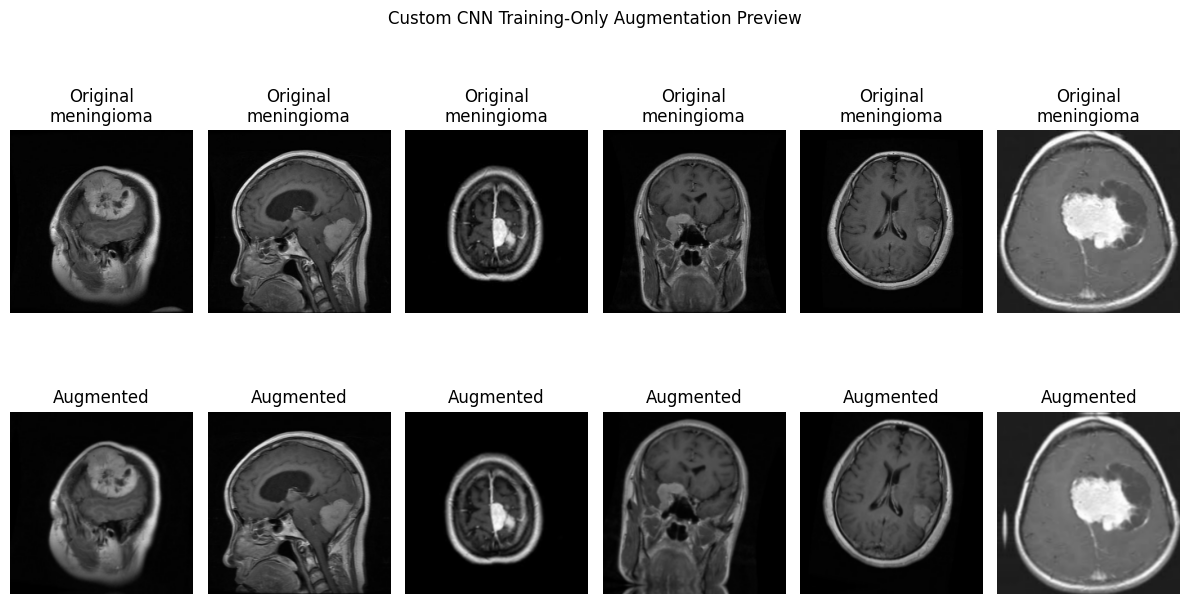

In [59]:
images, labels = next(iter(train_ds))

augmented_images = data_augmentation(
    images[:6],
    training=True
)


plt.figure(figsize=(12, 7))


for i in range(6):

    # Original
    plt.subplot(2, 6, i + 1)

    plt.imshow(
        tf.cast(
            images[i],
            tf.uint8
        )
    )

    class_name = EXPECTED_CLASSES[
        int(labels[i])
    ]

    plt.title(
        f"Original\n{class_name}"
    )

    plt.axis("off")


    # Augmented
    plt.subplot(2, 6, i + 7)

    clipped = tf.clip_by_value(
        augmented_images[i],
        0,
        255
    )

    plt.imshow(
        tf.cast(
            clipped,
            tf.uint8
        )
    )

    plt.title("Augmented")
    plt.axis("off")


plt.suptitle(
    "Custom CNN Training-Only Augmentation Preview"
)

plt.tight_layout()

plt.show()

In [60]:
def build_cnn_baseline():

    inputs = keras.Input(
        shape=(224, 224, 3),
        name="input_image"
    )

    # Training-only augmentation
    x = data_augmentation(inputs)

    # CNN-specific normalization
    x = layers.Rescaling(
        1.0 / 255.0,
        name="rescale_0_1"
    )(x)


    # Convolution Block 1
    x = layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation="relu",
        name="conv_1"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2,
        name="pool_1"
    )(x)


    # Convolution Block 2
    x = layers.Conv2D(
        filters=64,
        kernel_size=3,
        activation="relu",
        name="conv_2"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2,
        name="pool_2"
    )(x)


    # Convolution Block 3
    x = layers.Conv2D(
        filters=128,
        kernel_size=3,
        activation="relu",
        name="conv_3"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2,
        name="pool_3"
    )(x)


    # Convolution Block 4
    x = layers.Conv2D(
        filters=256,
        kernel_size=3,
        activation="relu",
        name="conv_4"
    )(x)

    # Kept for baseline comparability with reference design
    x = layers.MaxPooling2D(
        pool_size=5,
        name="pool_4"
    )(x)


    # Classifier
    x = layers.Flatten(
        name="flatten"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256"
    )(x)

    x = layers.Dropout(
        0.30,
        name="dropout_03"
    )(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="class_probabilities"
    )(x)


    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="CNN_A_Baseline"
    )

    return model


cnn_model = build_cnn_baseline()

cnn_model.summary()

Model: "CNN_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_4 (MaxPooling2D)           │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,438,276 (5.49 MB)

 Trainable params: 1,438,276 (5.49 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
RESULTS_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase2_smoke"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


total_params = cnn_model.count_params()

trainable_params = int(
    np.sum([
        np.prod(variable.shape)
        for variable in cnn_model.trainable_weights
    ])
)

non_trainable_params = (
    total_params - trainable_params
)


print("Total parameters:")
print(f"{total_params:,}")

print("\nTrainable parameters:")
print(f"{trainable_params:,}")

print("\nNon-trainable parameters:")
print(f"{non_trainable_params:,}")


# Save text summary
summary_lines = []

cnn_model.summary(
    print_fn=lambda line:
    summary_lines.append(line)
)

with open(
    RESULTS_DIR / "cnn_baseline_summary.txt",
    "w"
) as f:

    f.write(
        "\n".join(summary_lines)
    )

Total parameters:
1,438,276

Trainable parameters:
1,438,276

Non-trainable parameters:
0


In [62]:
INITIAL_LEARNING_RATE = 0.001


cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


print("CNN-A compiled successfully.")

print(
    "Optimizer:",
    cnn_model.optimizer.__class__.__name__
)

print(
    "Learning rate:",
    float(
        tf.keras.backend.get_value(
            cnn_model.optimizer.learning_rate
        )
    )
)

print(
    "Loss:",
    cnn_model.loss.__class__.__name__
)

CNN-A compiled successfully.
Optimizer: Adam
Learning rate: 0.0010000000474974513
Loss: SparseCategoricalCrossentropy


In [63]:
test_batch_images, test_batch_labels = next(
    iter(train_ds)
)


predictions_before_training = cnn_model(
    test_batch_images,
    training=False
)


print("Input batch:")
print(test_batch_images.shape)

print("\nOutput batch:")
print(predictions_before_training.shape)

print("\nFirst probability vector:")
print(predictions_before_training[0].numpy())

print("\nSum of first probability vector:")
print(
    float(
        tf.reduce_sum(
            predictions_before_training[0]
        )
    )
)


assert predictions_before_training.shape[1] == 4

np.testing.assert_allclose(
    tf.reduce_sum(
        predictions_before_training,
        axis=1
    ).numpy(),

    np.ones(
        len(predictions_before_training)
    ),

    atol=1e-5
)


print("\n✓ Four outputs verified.")
print("✓ Softmax probabilities sum to approximately 1.")

Input batch:
(16, 224, 224, 3)

Output batch:
(16, 4)

First probability vector:
[0.250207   0.2510698  0.255535   0.24318814]

Sum of first probability vector:
1.0

✓ Four outputs verified.
✓ Softmax probabilities sum to approximately 1.


In [64]:
normalization_probe = keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer(
        "rescale_0_1"
    ).output
)


normalized_batch = normalization_probe(
    test_batch_images,
    training=False
)


print(
    "Before model normalization:",
    float(tf.reduce_min(test_batch_images)),
    "to",
    float(tf.reduce_max(test_batch_images))
)

print(
    "\nAfter Rescaling(1./255):",
    float(tf.reduce_min(normalized_batch)),
    "to",
    float(tf.reduce_max(normalized_batch))
)


assert float(tf.reduce_min(normalized_batch)) >= 0.0

assert float(tf.reduce_max(normalized_batch)) <= 1.0001


print("\n✓ Custom CNN normalization verified.")

Before model normalization: 0.0 to 255.0

After Rescaling(1./255): 0.0 to 1.0

✓ Custom CNN normalization verified.


In [65]:
initial_val_loss, initial_val_accuracy = (
    cnn_model.evaluate(
        val_ds,
        verbose=1
    )
)


print("\nINITIAL VALIDATION STATE")
print(
    f"Loss: {initial_val_loss:.4f}"
)

print(
    f"Accuracy: {initial_val_accuracy:.4f}"
)

69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.2562 - loss: 1.3851

INITIAL VALIDATION STATE
Loss: 1.3851
Accuracy: 0.2562


In [66]:
SMOKE_CHECKPOINT = (
    RESULTS_DIR /
    "cnn_a_smoke_best.keras"
)


callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=str(
            SMOKE_CHECKPOINT
        ),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    keras.callbacks.TerminateOnNaN()
]


print("Checkpoint:")
print(SMOKE_CHECKPOINT)

Checkpoint:
/content/brain_tumour_model_comparison/results/cnn/phase2_smoke/cnn_a_smoke_best.keras


In [67]:
SMOKE_EPOCHS = 1


start_time = time.perf_counter()


smoke_history = cnn_model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=SMOKE_EPOCHS,

    callbacks=callbacks,

    verbose=1
)


smoke_training_seconds = (
    time.perf_counter()
    - start_time
)


print(
    f"\nSmoke-test duration: "
    f"{smoke_training_seconds:.2f} seconds"
)

273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4814 - loss: 1.1256
Epoch 1: val_loss improved from None to 0.87378, saving model to /content/brain_tumour_model_comparison/results/cnn/phase2_smoke/cnn_a_smoke_best.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase2_smoke/cnn_a_smoke_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.6081 - loss: 0.9097 - val_accuracy: 0.6474 - val_loss: 0.8738
Restoring model weights from the end of the best epoch: 1.

Smoke-test duration: 23.34 seconds


In [68]:
post_val_loss, post_val_accuracy = (
    cnn_model.evaluate(
        val_ds,
        verbose=1
    )
)


print("\n" + "=" * 60)
print("SMOKE TEST CHECK")
print("=" * 60)

print(
    f"Initial validation loss : "
    f"{initial_val_loss:.4f}"
)

print(
    f"Post-smoke val loss     : "
    f"{post_val_loss:.4f}"
)

print()

print(
    f"Initial validation acc  : "
    f"{initial_val_accuracy:.4f}"
)

print(
    f"Post-smoke val acc      : "
    f"{post_val_accuracy:.4f}"
)


if (
    np.isfinite(post_val_loss)
    and np.isfinite(post_val_accuracy)
):

    print("\n✓ Metrics are finite.")

else:

    raise RuntimeError(
        "NaN or infinite validation metric detected."
    )


if post_val_loss < initial_val_loss:

    print(
        "✓ Validation loss decreased after "
        "the smoke epoch."
    )

else:

    print(
        "NOTE: Validation loss did not decrease "
        "after one epoch. This alone does not prove "
        "the pipeline is broken; send me the output "
        "before Phase 3."
    )

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6474 - loss: 0.8738

SMOKE TEST CHECK
Initial validation loss : 1.3851
Post-smoke val loss     : 0.8738

Initial validation acc  : 0.2562
Post-smoke val acc      : 0.6474

✓ Metrics are finite.
✓ Validation loss decreased after the smoke epoch.


In [69]:
smoke_history_df = pd.DataFrame(
    smoke_history.history
)


smoke_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(smoke_history_df) + 1
    )
)


smoke_history_df.to_csv(
    RESULTS_DIR /
    "smoke_history.csv",
    index=False
)


display(smoke_history_df)

,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.608086,0.909686,0.647383,0.873783


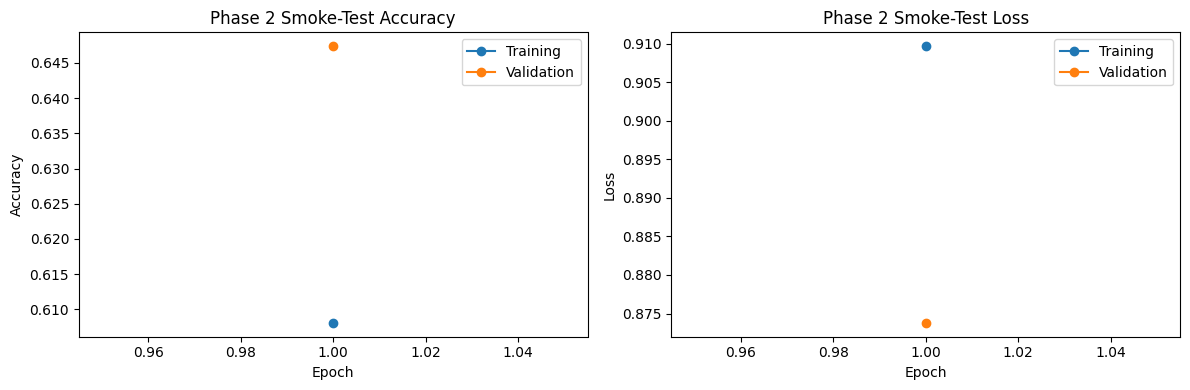

In [70]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)


axes[0].plot(
    smoke_history_df["epoch"],
    smoke_history_df["accuracy"],
    marker="o",
    label="Training"
)

axes[0].plot(
    smoke_history_df["epoch"],
    smoke_history_df["val_accuracy"],
    marker="o",
    label="Validation"
)

axes[0].set_title(
    "Phase 2 Smoke-Test Accuracy"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()


axes[1].plot(
    smoke_history_df["epoch"],
    smoke_history_df["loss"],
    marker="o",
    label="Training"
)

axes[1].plot(
    smoke_history_df["epoch"],
    smoke_history_df["val_loss"],
    marker="o",
    label="Validation"
)

axes[1].set_title(
    "Phase 2 Smoke-Test Loss"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()


plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "smoke_training_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [71]:
PHASE2_CONFIG = {
    "member": 1,

    "phase": 2,

    "model_name":
        "CNN_A_Baseline",

    "purpose":
        "1-epoch implementation smoke test only",

    "dataset_handle":
        PINNED_DATASET_HANDLE,

    "seed":
        SEED,

    "train_count":
        len(train_data),

    "validation_count":
        len(val_data),

    "test_count":
        len(test_df),

    "test_used_for_training_or_selection":
        False,

    "image_size":
        [224, 224, 3],

    "batch_size":
        BATCH_SIZE,

    "augmentation": {
        "rotation_factor": 0.03,
        "zoom": 0.08,
        "translation": 0.05
    },

    "normalization":
        "Rescaling(1./255)",

    "conv_filters":
        [32, 64, 128, 256],

    "kernel_size":
        [3, 3],

    "pool_sizes":
        [2, 2, 2, 5],

    "dense_units":
        256,

    "dropout":
        0.30,

    "output_units":
        4,

    "output_activation":
        "softmax",

    "optimizer":
        "Adam",

    "learning_rate":
        INITIAL_LEARNING_RATE,

    "loss":
        "SparseCategoricalCrossentropy",

    "smoke_epochs":
        1,

    "total_parameters":
        int(total_params),

    "trainable_parameters":
        int(trainable_params),

    "initial_val_loss":
        float(initial_val_loss),

    "initial_val_accuracy":
        float(initial_val_accuracy),

    "post_smoke_val_loss":
        float(post_val_loss),

    "post_smoke_val_accuracy":
        float(post_val_accuracy),

    "smoke_training_seconds":
        float(smoke_training_seconds)
}


with open(
    RESULTS_DIR /
    "phase2_config.json",
    "w"
) as f:

    json.dump(
        PHASE2_CONFIG,
        f,
        indent=4
    )


print(
    json.dumps(
        PHASE2_CONFIG,
        indent=4
    )
)

{
    "member": 1,
    "phase": 2,
    "model_name": "CNN_A_Baseline",
    "purpose": "1-epoch implementation smoke test only",
    "dataset_handle": "masoudnickparvar/brain-tumor-mri-dataset/versions/1",
    "seed": 42,
    "train_count": 4353,
    "validation_count": 1089,
    "test_count": 1311,
    "test_used_for_training_or_selection": false,
    "image_size": [
        224,
        224,
        3
    ],
    "batch_size": 16,
    "augmentation": {
        "rotation_factor": 0.03,
        "zoom": 0.08,
        "translation": 0.05
    },
    "normalization": "Rescaling(1./255)",
    "conv_filters": [
        32,
        64,
        128,
        256
    ],
    "kernel_size": [
        3,
        3
    ],
    "pool_sizes": [
        2,
        2,
        2,
        5
    ],
    "dense_units": 256,
    "dropout": 0.3,
    "output_units": 4,
    "output_activation": "softmax",
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss": "SparseCategoricalCrossentropy",
    "smoke_ep

In [72]:
print("=" * 75)
print("MEMBER 1 — PHASE 2 FINAL SUMMARY")
print("=" * 75)

print(
    "Model:",
    cnn_model.name
)

print(
    "Dataset:",
    PINNED_DATASET_HANDLE
)

print()

print(
    "Train samples:",
    len(train_data)
)

print(
    "Validation samples:",
    len(val_data)
)

print(
    "Test samples (LOCKED):",
    len(test_df)
)

print()

print(
    "Input shape:",
    cnn_model.input_shape
)

print(
    "Output shape:",
    cnn_model.output_shape
)

print()

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print()

print(
    "Optimizer:",
    cnn_model.optimizer.__class__.__name__
)

print(
    "Learning rate:",
    float(
        tf.keras.backend.get_value(
            cnn_model.optimizer.learning_rate
        )
    )
)

print()

print(
    "Initial val loss:",
    round(
        float(initial_val_loss),
        4
    )
)

print(
    "Post-smoke val loss:",
    round(
        float(post_val_loss),
        4
    )
)

print(
    "Post-smoke val accuracy:",
    round(
        float(post_val_accuracy),
        4
    )
)

print()

print(
    "Checkpoint exists:",
    SMOKE_CHECKPOINT.exists()
)

print()

print("TEST SET USED FOR MODEL SELECTION: NO")

print()
print("PHASE 2 STATUS:")
print("✓ Frozen manifests verified")
print("✓ Version 1 dataset loaded")
print("✓ tf.data pipeline works")
print("✓ Training-only augmentation works")
print("✓ Rescaling normalization verified")
print("✓ CNN-A architecture built")
print("✓ Four softmax outputs verified")
print("✓ Model compiled")
print("✓ Forward pass successful")
print("✓ Backpropagation successful")
print("✓ Validation pipeline successful")
print("✓ Checkpoint saving successful")
print("✓ 1-epoch smoke test completed")
print("✓ Test set untouched")

MEMBER 1 — PHASE 2 FINAL SUMMARY
Model: CNN_A_Baseline
Dataset: masoudnickparvar/brain-tumor-mri-dataset/versions/1

Train samples: 4353
Validation samples: 1089
Test samples (LOCKED): 1311

Input shape: (None, 224, 224, 3)
Output shape: (None, 4)

Total parameters: 1,438,276
Trainable parameters: 1,438,276

Optimizer: Adam
Learning rate: 0.0010000000474974513

Initial val loss: 1.3851
Post-smoke val loss: 0.8738
Post-smoke val accuracy: 0.6474

Checkpoint exists: True

TEST SET USED FOR MODEL SELECTION: NO

PHASE 2 STATUS:
✓ Frozen manifests verified
✓ Version 1 dataset loaded
✓ tf.data pipeline works
✓ Training-only augmentation works
✓ Rescaling normalization verified
✓ CNN-A architecture built
✓ Four softmax outputs verified
✓ Model compiled
✓ Forward pass successful
✓ Backpropagation successful
✓ Validation pipeline successful
✓ Checkpoint saving successful
✓ 1-epoch smoke test completed
✓ Test set untouched


In [73]:
print('Interactive ZIP/download export skipped during reproducibility Run All.')
print('All experiment artifacts are already written under PROJECT_DIR/results/.')

Saving current notebook...
✓ Notebook saved: /content/member1_phase2_export/notebooks/01_custom_cnn.ipynb

Copying Phase 2 files...
✓ cnn_a_smoke_best.keras
✓ cnn_baseline_summary.txt
✓ smoke_history.csv
✓ smoke_training_curves.png
✓ phase2_config.json

MEMBER 1 — PHASE 2 EXPORT COMPLETE
ZIP: /content/member1_cnn_phase2.zip
Size: 15.15 MB

Included files:
✓ notebooks/01_custom_cnn.ipynb
✓ results/cnn/phase2_smoke/cnn_a_smoke_best.keras
✓ results/cnn/phase2_smoke/cnn_baseline_summary.txt
✓ results/cnn/phase2_smoke/phase2_config.json
✓ results/cnn/phase2_smoke/smoke_history.csv
✓ results/cnn/phase2_smoke/smoke_training_curves.png

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
required_objects = [
    "train_data",
    "val_data",
    "create_dataset",
    "PROJECT_DIR",
    "EXPECTED_CLASSES",
    "CLASS_TO_INDEX",
    "BATCH_SIZE"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing Phase 2 setup objects: "
        + ", ".join(missing_objects)
        + "\nRerun Phase 2 setup Cells 1–16, "
          "but DO NOT rerun the smoke-test training."
    )


assert len(train_data) == 4353
assert len(val_data) == 1089
assert BATCH_SIZE == 16


print("✓ Phase 2 setup detected")
print("✓ Training samples:", len(train_data))
print("✓ Validation samples:", len(val_data))
print("✓ Batch size:", BATCH_SIZE)

print("\nTEST SET POLICY:")
print("LOCKED — not used anywhere in Phase 3")

✓ Phase 2 setup detected
✓ Training samples: 4353
✓ Validation samples: 1089
✓ Batch size: 16

TEST SET POLICY:
LOCKED — not used anywhere in Phase 3


In [75]:
import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [76]:
PHASE3_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase3_experiments"
)

CHECKPOINT_DIR = (
    PHASE3_DIR /
    "checkpoints"
)

HISTORY_DIR = (
    PHASE3_DIR /
    "histories"
)

PLOT_DIR = (
    PHASE3_DIR /
    "plots"
)

CONFIG_DIR = (
    PHASE3_DIR /
    "configs"
)

VALIDATION_DIR = (
    PHASE3_DIR /
    "validation_predictions"
)


for directory in [
    PHASE3_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    PLOT_DIR,
    CONFIG_DIR,
    VALIDATION_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("Phase 3 directory:")
print(PHASE3_DIR)

Phase 3 directory:
/content/brain_tumour_model_comparison/results/cnn/phase3_experiments


In [77]:
SEED = 42


def reset_experiment_state(seed=SEED):

    keras.backend.clear_session()
    gc.collect()

    import random

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

In [78]:
def make_augmentation(seed=SEED):

    return keras.Sequential(
        [
            layers.RandomRotation(
                factor=0.03,
                seed=seed,
                name="random_rotation"
            ),

            layers.RandomZoom(
                height_factor=(-0.08, 0.08),
                width_factor=(-0.08, 0.08),
                seed=seed,
                name="random_zoom"
            ),

            layers.RandomTranslation(
                height_factor=0.05,
                width_factor=0.05,
                seed=seed,
                name="random_translation"
            )
        ],
        name="training_augmentation"
    )

In [79]:
def build_experiment_datasets():

    train_dataset = create_dataset(
        train_data,
        training=True
    )

    validation_dataset = create_dataset(
        val_data,
        training=False
    )

    return train_dataset, validation_dataset

In [80]:
def build_custom_cnn(
    experiment_id,
    dropout_rate=0.30,
    use_global_average_pooling=False
):

    augmentation = make_augmentation(SEED)

    inputs = keras.Input(
        shape=(224, 224, 3),
        name="input_image"
    )

    # Training-only augmentation
    x = augmentation(inputs)

    # CNN normalization
    x = layers.Rescaling(
        1.0 / 255.0,
        name="rescale_0_1"
    )(x)


    # Block 1
    x = layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        name="conv_1"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2,
        name="pool_1"
    )(x)


    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=3,
        activation="relu",
        name="conv_2"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2,
        name="pool_2"
    )(x)


    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=3,
        activation="relu",
        name="conv_3"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=2,
        name="pool_3"
    )(x)


    # Block 4
    x = layers.Conv2D(
        256,
        kernel_size=3,
        activation="relu",
        name="conv_4"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=5,
        name="pool_4"
    )(x)


    # Controlled architectural change
    if use_global_average_pooling:

        x = layers.GlobalAveragePooling2D(
            name="global_average_pooling"
        )(x)

    else:

        x = layers.Flatten(
            name="flatten"
        )(x)


    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256"
    )(x)

    x = layers.Dropout(
        dropout_rate,
        name=f"dropout_{str(dropout_rate).replace('.', '_')}"
    )(x)


    outputs = layers.Dense(
        4,
        activation="softmax",
        name="class_probabilities"
    )(x)


    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=experiment_id
    )


    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss=keras.losses.SparseCategoricalCrossentropy(),

        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )


    return model

In [81]:
EXPERIMENTS = {

    "CNN_A": {
        "description":
            "Baseline: Flatten + Dense256 + Dropout 0.30",

        "dropout_rate":
            0.30,

        "use_global_average_pooling":
            False
    },


    "CNN_B": {
        "description":
            "Controlled dropout experiment: Dropout 0.50",

        "dropout_rate":
            0.50,

        "use_global_average_pooling":
            False
    },


    "CNN_C": {
        "description":
            "Controlled structural experiment: "
            "GlobalAveragePooling2D instead of Flatten",

        "dropout_rate":
            0.30,

        "use_global_average_pooling":
            True
    }
}


pd.DataFrame(EXPERIMENTS).T

,description,dropout_rate,use_global_average_pooling
CNN_A,Baseline: Flatten + Dense256 + Dropout 0.30,0.3,False
CNN_B,Controlled dropout experiment: Dropout 0.50,0.5,False
CNN_C,Controlled structural experiment: GlobalAverag...,0.3,True


In [82]:
def get_validation_metrics(
    model,
    validation_dataset,
    validation_dataframe
):

    probabilities = model.predict(
        validation_dataset,
        verbose=0
    )

    predicted_labels = np.argmax(
        probabilities,
        axis=1
    )


    true_labels = (
        validation_dataframe[
            "label_index"
        ]
        .astype(int)
        .values
    )


    metrics = {

        "val_accuracy_final":
            accuracy_score(
                true_labels,
                predicted_labels
            ),

        "val_macro_precision":
            precision_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0
            ),

        "val_macro_recall":
            recall_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0
            ),

        "val_macro_f1":
            f1_score(
                true_labels,
                predicted_labels,
                average="macro",
                zero_division=0
            )
    }


    predictions_df = pd.DataFrame({

        "filepath":
            validation_dataframe[
                "filepath"
            ].values,

        "true_label":
            validation_dataframe[
                "label"
            ].values,

        "true_index":
            true_labels,

        "predicted_index":
            predicted_labels,

        "predicted_label":
            [
                EXPECTED_CLASSES[index]
                for index in predicted_labels
            ]
    })


    for class_index, class_name in enumerate(
        EXPECTED_CLASSES
    ):

        predictions_df[
            f"prob_{class_name}"
        ] = probabilities[:, class_index]


    return metrics, predictions_df

In [83]:
def save_training_curves(
    history_df,
    experiment_id
):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["accuracy"],
        label="Training"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_accuracy"],
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{experiment_id} — Accuracy"
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        f"{experiment_id}_accuracy.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["loss"],
        label="Training"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{experiment_id} — Loss"
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        f"{experiment_id}_loss.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

In [84]:
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 4
LEARNING_RATE = 0.001


def run_cnn_experiment(
    experiment_id,
    configuration
):

    print("\n" + "=" * 75)
    print("STARTING:", experiment_id)
    print(configuration["description"])
    print("=" * 75)


    # -----------------------------------------------------
    # Reset state
    # -----------------------------------------------------

    reset_experiment_state(SEED)


    # -----------------------------------------------------
    # Fresh data pipelines
    # -----------------------------------------------------

    train_dataset, validation_dataset = (
        build_experiment_datasets()
    )


    # -----------------------------------------------------
    # Model
    # -----------------------------------------------------

    model = build_custom_cnn(
        experiment_id=experiment_id,

        dropout_rate=
            configuration["dropout_rate"],

        use_global_average_pooling=
            configuration[
                "use_global_average_pooling"
            ]
    )


    total_parameters = model.count_params()

    trainable_parameters = int(
        np.sum([
            np.prod(weight.shape)
            for weight in model.trainable_weights
        ])
    )


    print("\nTotal parameters:")
    print(f"{total_parameters:,}")

    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )


    # -----------------------------------------------------
    # Checkpoint
    # -----------------------------------------------------

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"{experiment_id}_best.keras"
    )


    callbacks = [

        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1
        ),

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.TerminateOnNaN()
    ]


    # -----------------------------------------------------
    # Train
    # -----------------------------------------------------

    start_time = time.perf_counter()


    history = model.fit(
        train_dataset,

        validation_data=
            validation_dataset,

        epochs=
            MAX_EPOCHS,

        callbacks=
            callbacks,

        verbose=1
    )


    training_seconds = (
        time.perf_counter()
        - start_time
    )


    # -----------------------------------------------------
    # History
    # -----------------------------------------------------

    history_df = pd.DataFrame(
        history.history
    )

    history_df.insert(
        0,
        "epoch",
        np.arange(
            1,
            len(history_df) + 1
        )
    )


    history_path = (
        HISTORY_DIR /
        f"{experiment_id}_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )


    # -----------------------------------------------------
    # Determine best validation epoch
    # -----------------------------------------------------

    best_index = int(
        history_df[
            "val_loss"
        ].idxmin()
    )

    best_epoch = int(
        history_df.loc[
            best_index,
            "epoch"
        ]
    )

    best_val_loss = float(
        history_df.loc[
            best_index,
            "val_loss"
        ]
    )

    best_val_accuracy = float(
        history_df.loc[
            best_index,
            "val_accuracy"
        ]
    )

    train_accuracy_at_best_epoch = float(
        history_df.loc[
            best_index,
            "accuracy"
        ]
    )

    train_loss_at_best_epoch = float(
        history_df.loc[
            best_index,
            "loss"
        ]
    )


    # -----------------------------------------------------
    # Explicitly reload best validation-loss checkpoint
    # -----------------------------------------------------

    best_model = keras.models.load_model(
        checkpoint_path
    )


    # -----------------------------------------------------
    # Validation metrics
    # -----------------------------------------------------

    validation_metrics, predictions_df = (
        get_validation_metrics(
            best_model,
            validation_dataset,
            val_data
        )
    )


    predictions_df.to_csv(
        VALIDATION_DIR /
        f"{experiment_id}_validation_predictions.csv",
        index=False
    )


    # -----------------------------------------------------
    # Generalization gap
    # -----------------------------------------------------

    accuracy_gap = (
        train_accuracy_at_best_epoch
        - best_val_accuracy
    )


    # -----------------------------------------------------
    # Save plots
    # -----------------------------------------------------

    save_training_curves(
        history_df,
        experiment_id
    )


    # -----------------------------------------------------
    # Save experiment configuration
    # -----------------------------------------------------

    saved_config = {

        "experiment_id":
            experiment_id,

        "description":
            configuration["description"],

        "dataset_version":
            1,

        "seed":
            SEED,

        "image_size":
            [224, 224, 3],

        "batch_size":
            16,

        "optimizer":
            "Adam",

        "learning_rate":
            LEARNING_RATE,

        "loss":
            "SparseCategoricalCrossentropy",

        "max_epochs":
            MAX_EPOCHS,

        "early_stopping_patience":
            EARLY_STOPPING_PATIENCE,

        "early_stopping_monitor":
            "val_loss",

        "dropout":
            configuration["dropout_rate"],

        "global_average_pooling":
            configuration[
                "use_global_average_pooling"
            ],

        "test_set_used":
            False,

        "total_parameters":
            int(total_parameters),

        "trainable_parameters":
            int(trainable_parameters)
    }


    with open(
        CONFIG_DIR /
        f"{experiment_id}_config.json",
        "w"
    ) as file:

        json.dump(
            saved_config,
            file,
            indent=4
        )


    # -----------------------------------------------------
    # Return summary
    # -----------------------------------------------------

    summary = {

        "model":
            "Custom CNN",

        "experiment_id":
            experiment_id,

        "description":
            configuration["description"],

        "dropout":
            configuration["dropout_rate"],

        "global_average_pooling":
            configuration[
                "use_global_average_pooling"
            ],

        "image_size":
            "224x224",

        "batch_size":
            16,

        "optimizer":
            "Adam",

        "learning_rate":
            LEARNING_RATE,

        "max_epochs":
            MAX_EPOCHS,

        "actual_epochs":
            len(history_df),

        "best_epoch":
            best_epoch,

        "train_loss_at_best_epoch":
            train_loss_at_best_epoch,

        "best_val_loss":
            best_val_loss,

        "train_accuracy_at_best_epoch":
            train_accuracy_at_best_epoch,

        "best_val_accuracy":
            best_val_accuracy,

        "validation_accuracy":
            validation_metrics[
                "val_accuracy_final"
            ],

        "validation_macro_precision":
            validation_metrics[
                "val_macro_precision"
            ],

        "validation_macro_recall":
            validation_metrics[
                "val_macro_recall"
            ],

        "validation_macro_f1":
            validation_metrics[
                "val_macro_f1"
            ],

        "accuracy_generalization_gap":
            accuracy_gap,

        "training_time_seconds":
            training_seconds,

        "total_parameters":
            int(total_parameters),

        "trainable_parameters":
            int(trainable_parameters),

        "seed":
            SEED,

        # TEST FIELDS MUST REMAIN EMPTY
        "test_accuracy":
            np.nan,

        "test_macro_precision":
            np.nan,

        "test_macro_recall":
            np.nan,

        "test_macro_f1":
            np.nan
    }


    print("\n" + "-" * 75)
    print("EXPERIMENT COMPLETE:", experiment_id)
    print("-" * 75)

    print(
        "Actual epochs:",
        summary["actual_epochs"]
    )

    print(
        "Best epoch:",
        summary["best_epoch"]
    )

    print(
        "Best validation loss:",
        round(
            summary["best_val_loss"],
            4
        )
    )

    print(
        "Best validation accuracy:",
        round(
            summary["best_val_accuracy"],
            4
        )
    )

    print(
        "Validation Macro F1:",
        round(
            summary["validation_macro_f1"],
            4
        )
    )

    print(
        "Generalization accuracy gap:",
        round(
            summary[
                "accuracy_generalization_gap"
            ],
            4
        )
    )

    print(
        "Training time:",
        round(
            training_seconds,
            2
        ),
        "seconds"
    )


    return summary


STARTING: CNN_A
Baseline: Flatten + Dense256 + Dropout 0.30

Total parameters:
1,438,276
Trainable parameters: 1,438,276
Epoch 1/20
271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4934 - loss: 1.0689
Epoch 1: val_loss improved from None to 0.96298, saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_A_best.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_A_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.6125 - loss: 0.8889 - val_accuracy: 0.5941 - val_loss: 0.9630
Epoch 2/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7485 - loss: 0.6279
Epoch 2: val_loss improved from 0.96298 to 0.88222, saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_A_best.keras

Epoch 2: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN

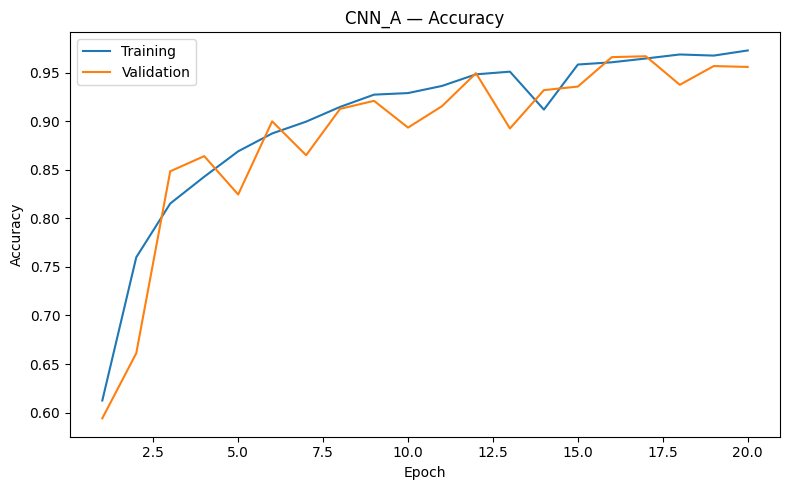

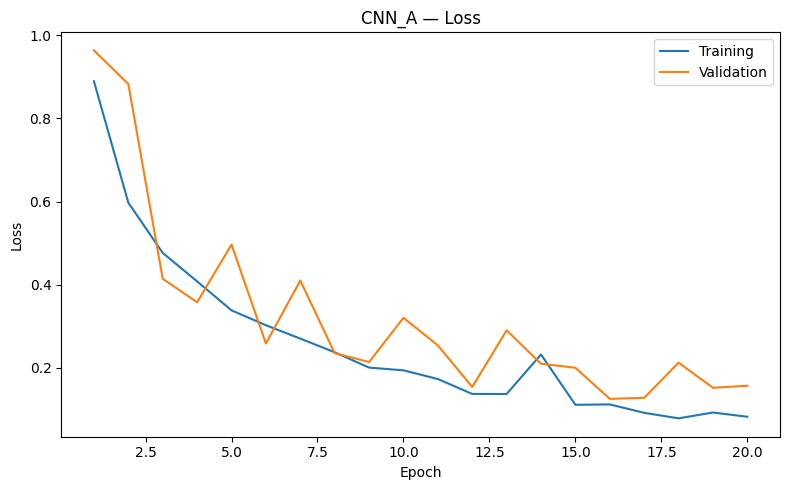


---------------------------------------------------------------------------
EXPERIMENT COMPLETE: CNN_A
---------------------------------------------------------------------------
Actual epochs: 20
Best epoch: 16
Best validation loss: 0.1258
Best validation accuracy: 0.966
Validation Macro F1: 0.9655
Generalization accuracy gap: -0.0053
Training time: 331.96 seconds


In [85]:
cnn_a_result = run_cnn_experiment(
    "CNN_A",
    EXPERIMENTS["CNN_A"]
)


STARTING: CNN_B
Controlled dropout experiment: Dropout 0.50

Total parameters:
1,438,276
Trainable parameters: 1,438,276
Epoch 1/20
271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4807 - loss: 1.0896
Epoch 1: val_loss improved from None to 1.61658, saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_B_best.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_B_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.5934 - loss: 0.9273 - val_accuracy: 0.4068 - val_loss: 1.6166
Epoch 2/20
271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7161 - loss: 0.7204
Epoch 2: val_loss improved from 1.61658 to 0.55767, saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_B_best.keras

Epoch 2: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN

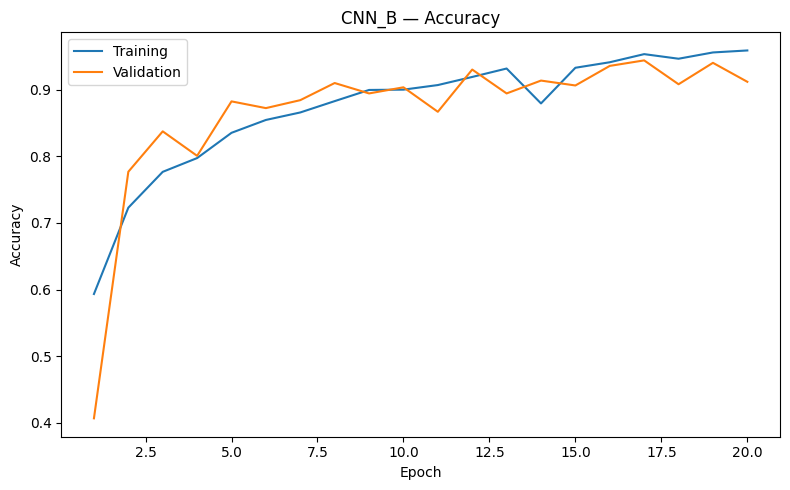

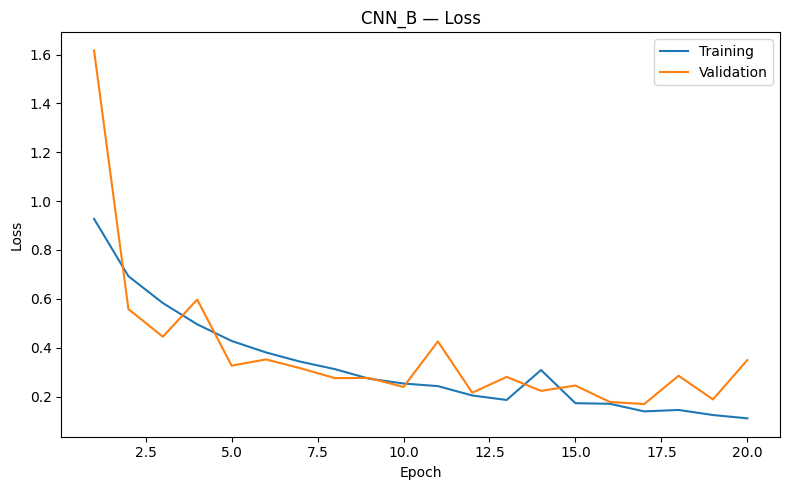


---------------------------------------------------------------------------
EXPERIMENT COMPLETE: CNN_B
---------------------------------------------------------------------------
Actual epochs: 20
Best epoch: 17
Best validation loss: 0.1691
Best validation accuracy: 0.944
Validation Macro F1: 0.9434
Generalization accuracy gap: 0.0094
Training time: 287.48 seconds


In [86]:
cnn_b_result = run_cnn_experiment(
    "CNN_B",
    EXPERIMENTS["CNN_B"]
)


STARTING: CNN_C
Controlled structural experiment: GlobalAveragePooling2D instead of Flatten

Total parameters:
455,236
Trainable parameters: 455,236
Epoch 1/20
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3926 - loss: 1.2105
Epoch 1: val_loss improved from None to 1.63727, saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_C_best.keras

Epoch 1: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_C_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.4790 - loss: 1.1032 - val_accuracy: 0.3802 - val_loss: 1.6373
Epoch 2/20
271/273 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6702 - loss: 0.8100
Epoch 2: val_loss improved from 1.63727 to 0.73445, saving model to /content/brain_tumour_model_comparison/results/cnn/phase3_experiments/checkpoints/CNN_C_best.keras

Epoch 2: finished saving model to /content/brain_tumour_model_comparison/results/cnn/phase3

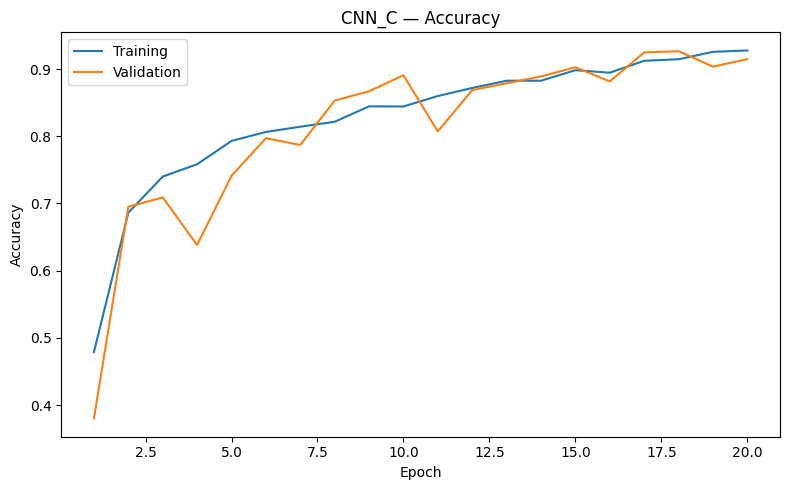

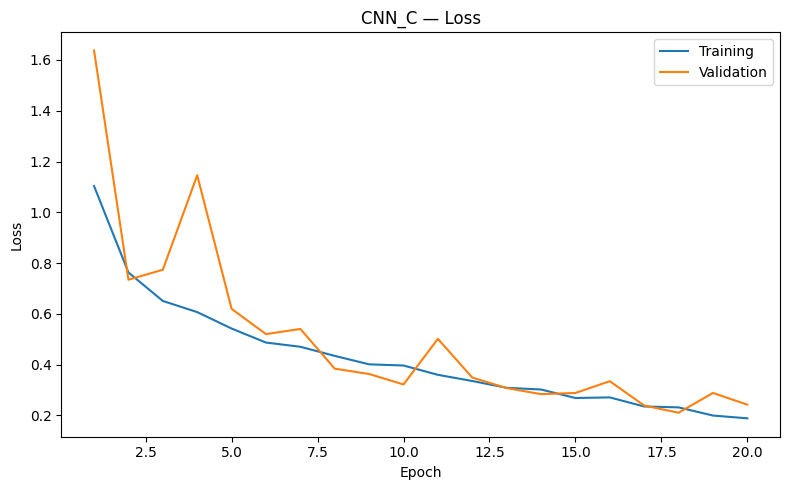


---------------------------------------------------------------------------
EXPERIMENT COMPLETE: CNN_C
---------------------------------------------------------------------------
Actual epochs: 20
Best epoch: 18
Best validation loss: 0.2107
Best validation accuracy: 0.9265
Validation Macro F1: 0.9249
Generalization accuracy gap: -0.012
Training time: 294.74 seconds


In [87]:
cnn_c_result = run_cnn_experiment(
    "CNN_C",
    EXPERIMENTS["CNN_C"]
)

In [88]:
experiment_results = pd.DataFrame([
    cnn_a_result,
    cnn_b_result,
    cnn_c_result
])


experiment_results.to_csv(
    PHASE3_DIR /
    "cnn_phase3_experiment_summary.csv",
    index=False
)


comparison_columns = [
    "experiment_id",
    "dropout",
    "global_average_pooling",
    "actual_epochs",
    "best_epoch",
    "best_val_loss",
    "best_val_accuracy",
    "validation_macro_precision",
    "validation_macro_recall",
    "validation_macro_f1",
    "accuracy_generalization_gap",
    "training_time_seconds",
    "total_parameters"
]


display(
    experiment_results[
        comparison_columns
    ]
)

,experiment_id,dropout,global_average_pooling,actual_epochs,best_epoch,best_val_loss,best_val_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,accuracy_generalization_gap,training_time_seconds,total_parameters
0,CNN_A,0.3,False,20,16,0.125765,0.966024,0.965559,0.965596,0.965485,-0.005307,331.956820,1438276
1,CNN_B,0.5,False,20,17,0.169082,0.943985,0.944578,0.943242,0.943384,0.009380,287.476716,1438276
2,CNN_C,0.3,True,20,18,0.210721,0.926538,0.925196,0.925505,0.924904,-0.011996,294.739004,455236


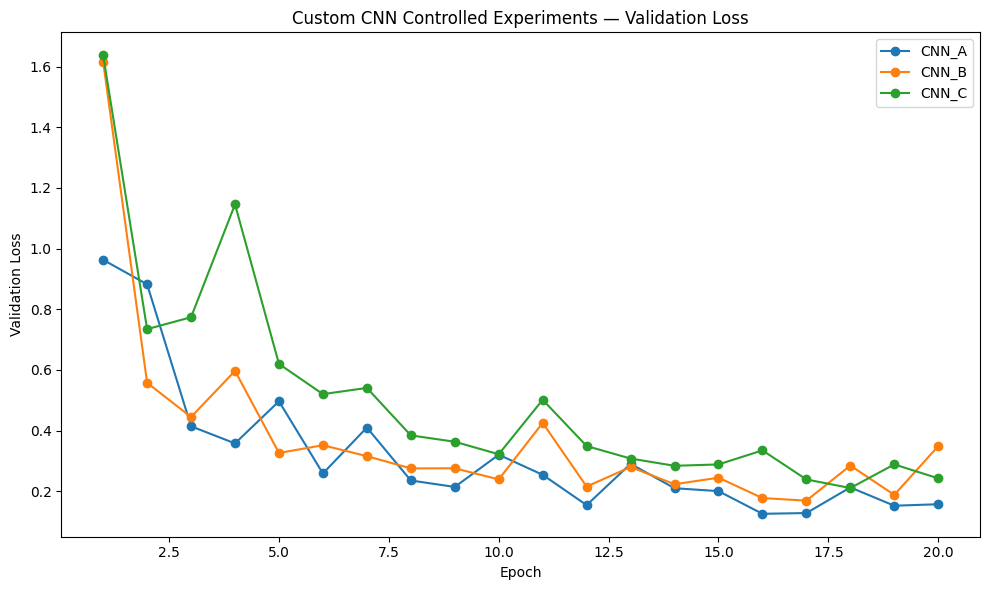

In [89]:
plt.figure(figsize=(10, 6))


for experiment_id in EXPERIMENTS.keys():

    history_df = pd.read_csv(
        HISTORY_DIR /
        f"{experiment_id}_history.csv"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label=experiment_id
    )


plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Custom CNN Controlled Experiments — Validation Loss"
)

plt.legend()
plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "cnn_validation_loss_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

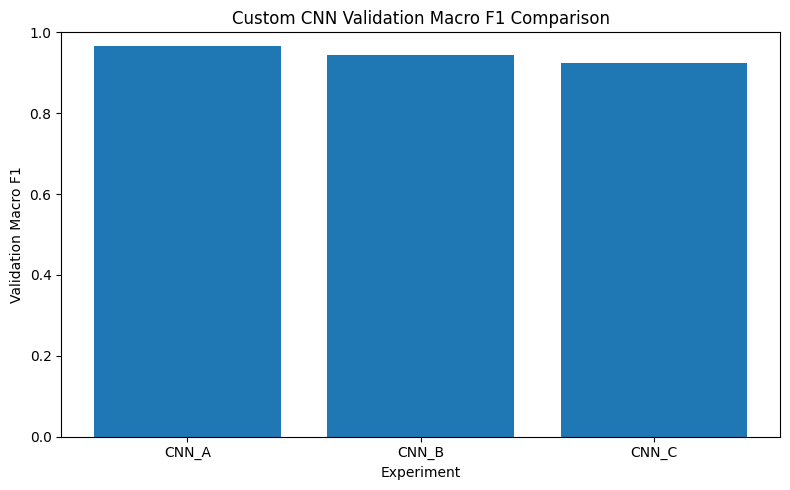

In [90]:
plt.figure(figsize=(8, 5))


plt.bar(
    experiment_results[
        "experiment_id"
    ],
    experiment_results[
        "validation_macro_f1"
    ]
)


plt.ylim(
    0,
    1
)

plt.xlabel("Experiment")
plt.ylabel("Validation Macro F1")

plt.title(
    "Custom CNN Validation Macro F1 Comparison"
)

plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "cnn_validation_macro_f1_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

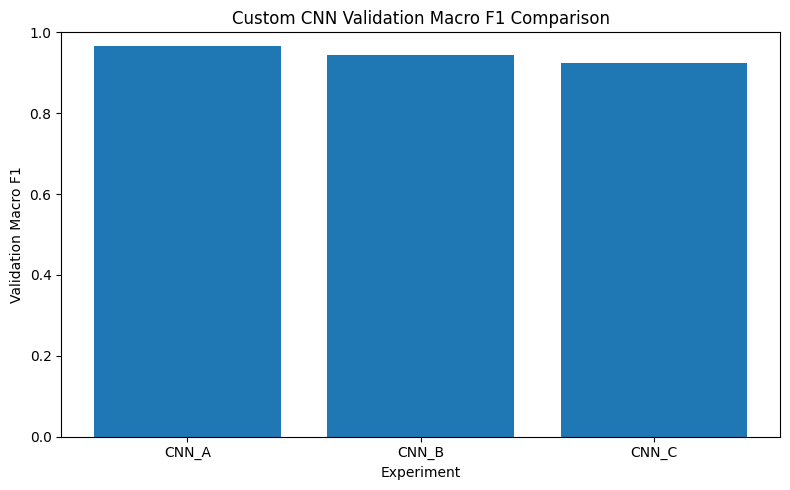

In [91]:
plt.figure(figsize=(8, 5))


plt.bar(
    experiment_results[
        "experiment_id"
    ],
    experiment_results[
        "validation_macro_f1"
    ]
)


plt.ylim(
    0,
    1
)

plt.xlabel("Experiment")
plt.ylabel("Validation Macro F1")

plt.title(
    "Custom CNN Validation Macro F1 Comparison"
)

plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "cnn_validation_macro_f1_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

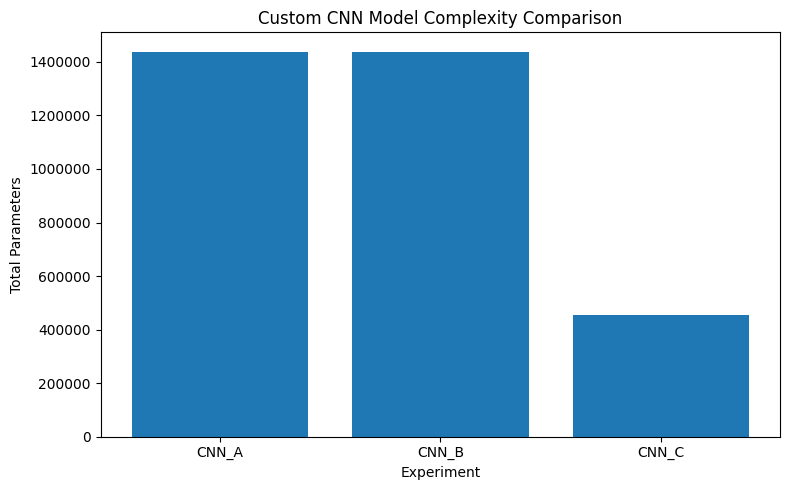

In [92]:
plt.figure(figsize=(8, 5))


plt.bar(
    experiment_results[
        "experiment_id"
    ],
    experiment_results[
        "total_parameters"
    ]
)


plt.xlabel("Experiment")
plt.ylabel("Total Parameters")

plt.title(
    "Custom CNN Model Complexity Comparison"
)

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "cnn_parameter_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [93]:
selection_table = experiment_results.copy()


selection_table = selection_table.sort_values(
    by=[
        "best_val_loss",
        "validation_macro_f1"
    ],
    ascending=[
        True,
        False
    ]
).reset_index(drop=True)


display(
    selection_table[
        [
            "experiment_id",
            "best_val_loss",
            "validation_macro_f1",
            "best_val_accuracy",
            "accuracy_generalization_gap",
            "total_parameters"
        ]
    ]
)


SELECTED_EXPERIMENT = (
    selection_table.loc[
        0,
        "experiment_id"
    ]
)


print(
    "\nSelected CNN configuration:",
    SELECTED_EXPERIMENT
)

print(
    "\nSelection basis:"
)

print(
    "1. Lowest best validation loss"
)

print(
    "2. Validation Macro F1 used as secondary evidence"
)

print(
    "3. Test set was NOT inspected"
)

,experiment_id,best_val_loss,validation_macro_f1,best_val_accuracy,accuracy_generalization_gap,total_parameters
0,CNN_A,0.125765,0.965485,0.966024,-0.005307,1438276
1,CNN_B,0.169082,0.943384,0.943985,0.009380,1438276
2,CNN_C,0.210721,0.924904,0.926538,-0.011996,455236



Selected CNN configuration: CNN_A

Selection basis:
1. Lowest best validation loss
2. Validation Macro F1 used as secondary evidence
3. Test set was NOT inspected


In [94]:
selected_row = (
    selection_table
    .iloc[0]
    .to_dict()
)


selected_configuration = {

    "selected_experiment":
        SELECTED_EXPERIMENT,

    "selection_primary_metric":
        "minimum validation loss",

    "selection_secondary_metric":
        "validation macro F1",

    "test_set_used_for_selection":
        False,

    "experiment_results":
        {
            key:
                (
                    value.item()
                    if isinstance(
                        value,
                        np.generic
                    )
                    else value
                )

            for key, value
            in selected_row.items()

            if not (
                isinstance(value, float)
                and np.isnan(value)
            )
        }
}


SELECTED_CONFIG_PATH = (
    PHASE3_DIR /
    "selected_cnn_configuration.json"
)


with open(
    SELECTED_CONFIG_PATH,
    "w"
) as file:

    json.dump(
        selected_configuration,
        file,
        indent=4,
        default=str
    )


print(
    json.dumps(
        selected_configuration,
        indent=4,
        default=str
    )
)

{
    "selected_experiment": "CNN_A",
    "selection_primary_metric": "minimum validation loss",
    "selection_secondary_metric": "validation macro F1",
    "test_set_used_for_selection": false,
    "experiment_results": {
        "model": "Custom CNN",
        "experiment_id": "CNN_A",
        "description": "Baseline: Flatten + Dense256 + Dropout 0.30",
        "dropout": 0.3,
        "global_average_pooling": false,
        "image_size": "224x224",
        "batch_size": 16,
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "max_epochs": 20,
        "actual_epochs": 20,
        "best_epoch": 16,
        "train_loss_at_best_epoch": 0.11247526854276657,
        "best_val_loss": 0.12576526403427124,
        "train_accuracy_at_best_epoch": 0.960716724395752,
        "best_val_accuracy": 0.966023862361908,
        "validation_accuracy": 0.9660238751147842,
        "validation_macro_precision": 0.9655592365419832,
        "validation_macro_recall": 0.9655960352589567,
 

In [95]:
selected_checkpoint = (
    CHECKPOINT_DIR /
    f"{SELECTED_EXPERIMENT}_best.keras"
)


FINAL_CNN_CHECKPOINT = (
    PHASE3_DIR /
    "selected_cnn_best.keras"
)


shutil.copy2(
    selected_checkpoint,
    FINAL_CNN_CHECKPOINT
)


print("Selected model checkpoint:")
print(FINAL_CNN_CHECKPOINT)

print(
    "\nExists:",
    FINAL_CNN_CHECKPOINT.exists()
)

print(
    "Size:",
    round(
        FINAL_CNN_CHECKPOINT.stat().st_size
        / (1024 * 1024),
        2
    ),
    "MB"
)

Selected model checkpoint:
/content/brain_tumour_model_comparison/results/cnn/phase3_experiments/selected_cnn_best.keras

Exists: True
Size: 16.53 MB


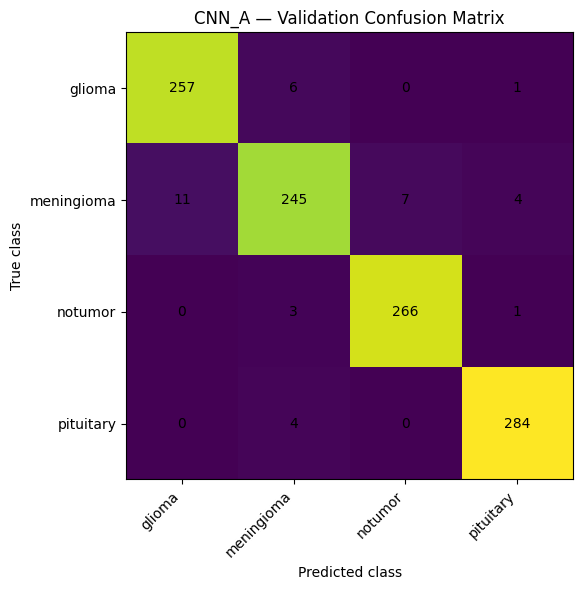

In [48]:
selected_predictions = pd.read_csv(
    VALIDATION_DIR /
    f"{SELECTED_EXPERIMENT}_validation_predictions.csv"
)


cm = confusion_matrix(
    selected_predictions["true_index"],
    selected_predictions["predicted_index"],
    labels=[0, 1, 2, 3]
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


image = ax.imshow(cm)


ax.set_xticks(
    range(4)
)

ax.set_yticks(
    range(4)
)

ax.set_xticklabels(
    EXPECTED_CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    EXPECTED_CLASSES
)


ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    f"{SELECTED_EXPERIMENT} — Validation Confusion Matrix"
)


for i in range(4):

    for j in range(4):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "selected_cnn_validation_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [96]:
validation_report = classification_report(
    selected_predictions["true_index"],
    selected_predictions["predicted_index"],

    target_names=
        EXPECTED_CLASSES,

    digits=4,

    output_dict=True,

    zero_division=0
)


validation_report_df = (
    pd.DataFrame(
        validation_report
    )
    .transpose()
)


display(validation_report_df)


validation_report_df.to_csv(
    PHASE3_DIR /
    "selected_cnn_validation_classification_report.csv"
)

,precision,recall,f1-score,support
glioma,0.958955,0.973485,0.966165,264.000000
meningioma,0.949612,0.917603,0.933333,267.000000
notumor,0.974359,0.985185,0.979742,270.000000
pituitary,0.979310,0.986111,0.982699,288.000000
accuracy,0.966024,0.966024,0.966024,0.966024
macro avg,0.965559,0.965596,0.965485,1089.000000
weighted avg,0.965867,0.966024,0.965854,1089.000000


In [97]:
selected_result = (
    experiment_results[
        experiment_results[
            "experiment_id"
        ] == SELECTED_EXPERIMENT
    ]
    .iloc[0]
)


gap = float(
    selected_result[
        "accuracy_generalization_gap"
    ]
)


print("Selected model:", SELECTED_EXPERIMENT)

print(
    "Training accuracy at selected epoch:",
    round(
        selected_result[
            "train_accuracy_at_best_epoch"
        ],
        4
    )
)

print(
    "Validation accuracy:",
    round(
        selected_result[
            "best_val_accuracy"
        ],
        4
    )
)

print(
    "Accuracy generalization gap:",
    round(gap, 4)
)


if gap > 0.10:

    print(
        "\nObservation: A relatively large "
        "training-validation accuracy gap exists."
    )

    print(
        "This may indicate overfitting and should "
        "be discussed together with the learning curves."
    )

elif gap > 0.03:

    print(
        "\nObservation: A moderate "
        "training-validation gap exists."
    )

else:

    print(
        "\nObservation: Training and validation "
        "accuracy are relatively close."
    )


print(
    "\nDo not base the discussion on this gap alone; "
    "also inspect validation loss and learning curves."
)

Selected model: CNN_A
Training accuracy at selected epoch: 0.9607
Validation accuracy: 0.966
Accuracy generalization gap: -0.0053

Observation: Training and validation accuracy are relatively close.

Do not base the discussion on this gap alone; also inspect validation loss and learning curves.


In [98]:
print("=" * 80)
print("MEMBER 1 — PHASE 3 FINAL SUMMARY")
print("=" * 80)


display(
    experiment_results[
        [
            "experiment_id",
            "actual_epochs",
            "best_epoch",
            "best_val_loss",
            "best_val_accuracy",
            "validation_macro_precision",
            "validation_macro_recall",
            "validation_macro_f1",
            "accuracy_generalization_gap",
            "training_time_seconds",
            "total_parameters"
        ]
    ]
)


print("\nSELECTED CONFIGURATION")
print("-" * 40)

print(
    "Experiment:",
    SELECTED_EXPERIMENT
)

print(
    "Selection criterion:",
    "lowest validation loss"
)

print(
    "Secondary evidence:",
    "validation Macro F1"
)


print(
    "\nSelected checkpoint:"
)

print(
    FINAL_CNN_CHECKPOINT
)


print(
    "\nTEST SET USED:"
)

print(
    "NO — still locked"
)


print(
    "\nPHASE 3 STATUS:"
)

print("✓ CNN-A trained")
print("✓ CNN-B trained")
print("✓ CNN-C trained")
print("✓ Same data split used")
print("✓ Same augmentation used")
print("✓ Same optimizer used")
print("✓ Same learning rate used")
print("✓ Same epoch budget used")
print("✓ Early stopping used")
print("✓ Validation metrics recorded")
print("✓ Training time recorded")
print("✓ Parameter counts recorded")
print("✓ Generalization gaps recorded")
print("✓ Controlled comparison completed")
print("✓ Final CNN configuration frozen")
print("✓ Test set remains untouched")

MEMBER 1 — PHASE 3 FINAL SUMMARY


,experiment_id,actual_epochs,best_epoch,best_val_loss,best_val_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,accuracy_generalization_gap,training_time_seconds,total_parameters
0,CNN_A,20,16,0.125765,0.966024,0.965559,0.965596,0.965485,-0.005307,331.956820,1438276
1,CNN_B,20,17,0.169082,0.943985,0.944578,0.943242,0.943384,0.009380,287.476716,1438276
2,CNN_C,20,18,0.210721,0.926538,0.925196,0.925505,0.924904,-0.011996,294.739004,455236



SELECTED CONFIGURATION
----------------------------------------
Experiment: CNN_A
Selection criterion: lowest validation loss
Secondary evidence: validation Macro F1

Selected checkpoint:
/content/brain_tumour_model_comparison/results/cnn/phase3_experiments/selected_cnn_best.keras

TEST SET USED:
NO — still locked

PHASE 3 STATUS:
✓ CNN-A trained
✓ CNN-B trained
✓ CNN-C trained
✓ Same data split used
✓ Same augmentation used
✓ Same optimizer used
✓ Same learning rate used
✓ Same epoch budget used
✓ Early stopping used
✓ Validation metrics recorded
✓ Training time recorded
✓ Parameter counts recorded
✓ Generalization gaps recorded
✓ Controlled comparison completed
✓ Final CNN configuration frozen
✓ Test set remains untouched


In [99]:
print('Interactive ZIP/download export skipped during reproducibility Run All.')
print('All experiment artifacts are already written under PROJECT_DIR/results/.')

PACKAGING MEMBER 1 — PHASE 1 TO PHASE 3

Important file check:
✓ splits/train.csv
✓ splits/val.csv
✓ splits/test.csv
✓ splits/split_checksums.json
✓ config/shared_protocol.json
✓ config/environment.json
✓ config/phase1_config.json
✓ results/cnn/phase2_smoke/phase2_config.json
✓ results/cnn/phase3_experiments/cnn_phase3_experiment_summary.csv
✓ results/cnn/phase3_experiments/selected_cnn_configuration.json
✓ results/cnn/phase3_experiments/selected_cnn_best.keras

ZIP CREATED SUCCESSFULLY
File:
/content/member1_cnn_phase1_to_phase3.zip

ZIP size: 67.19 MB

The Kaggle MRI dataset is NOT included.

Keep this ZIP safely. It contains the frozen splits and Member 1 results through Phase 3.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
import os
import json
import time
import platform
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [101]:
PHASE3_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase3_experiments"
)

SELECTED_CONFIG_PATH = (
    PHASE3_DIR /
    "selected_cnn_configuration.json"
)

FINAL_CNN_CHECKPOINT = (
    PHASE3_DIR /
    "selected_cnn_best.keras"
)


assert SELECTED_CONFIG_PATH.exists(), (
    "selected_cnn_configuration.json is missing."
)

assert FINAL_CNN_CHECKPOINT.exists(), (
    "selected_cnn_best.keras is missing."
)


with open(
    SELECTED_CONFIG_PATH,
    "r"
) as file:

    selected_config = json.load(file)


SELECTED_EXPERIMENT = (
    selected_config[
        "selected_experiment"
    ]
)


print("Frozen CNN configuration:")
print(SELECTED_EXPERIMENT)

print("\nCheckpoint:")
print(FINAL_CNN_CHECKPOINT)

print("\nTEST SET STATUS:")
print("Ready for FIRST final evaluation.")

Frozen CNN configuration:
CNN_A

Checkpoint:
/content/brain_tumour_model_comparison/results/cnn/phase3_experiments/selected_cnn_best.keras

TEST SET STATUS:
Ready for FIRST final evaluation.


In [102]:
final_cnn_model = keras.models.load_model(
    FINAL_CNN_CHECKPOINT
)


print(
    "Loaded model:",
    final_cnn_model.name
)

print(
    "Input shape:",
    final_cnn_model.input_shape
)

print(
    "Output shape:",
    final_cnn_model.output_shape
)

print(
    "Total parameters:",
    f"{final_cnn_model.count_params():,}"
)

Loaded model: CNN_A
Input shape: (None, 224, 224, 3)
Output shape: (None, 4)
Total parameters: 1,438,276


In [103]:
def prepare_test_manifest(manifest_df):

    df = manifest_df.copy()

    df["label_index"] = (
        df["label"]
        .map(CLASS_TO_INDEX)
        .astype("int32")
    )

    df["absolute_path"] = (
        df["filepath"]
        .apply(
            lambda relative_path:
            str(DATASET_ROOT / relative_path)
        )
    )

    return df


test_data = prepare_test_manifest(
    test_df
)


assert len(test_data) == 1311

assert sorted(
    test_data["label"].unique()
) == EXPECTED_CLASSES


missing_test_files = [
    path
    for path in test_data[
        "absolute_path"
    ]
    if not Path(path).exists()
]


assert len(missing_test_files) == 0


print("Test images:", len(test_data))

print("\nTest class distribution:")

display(
    test_data[
        "label"
    ]
    .value_counts()
    .reindex(EXPECTED_CLASSES)
)

Test images: 1311

Test class distribution:


,count
label,
glioma,300
meningioma,306
notumor,405
pituitary,300


In [124]:
test_ds = create_dataset(
    test_data,
    training=False
)


print(test_ds)


test_images, test_labels = next(
    iter(test_ds)
)


print("\nBatch shape:")
print(test_images.shape)

print("\nLabel shape:")
print(test_labels.shape)


assert test_images.shape[1:] == (
    224,
    224,
    3
)


print("\n✓ Test pipeline ready.")
print("✓ shuffle=False behaviour preserved.")

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

Batch shape:
(16, 224, 224, 3)

Label shape:
(16,)

✓ Test pipeline ready.
✓ shuffle=False behaviour preserved.


In [125]:
PHASE4_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase4_final_test"
)

PLOTS_DIR = (
    PHASE4_DIR /
    "plots"
)

ERROR_DIR = (
    PHASE4_DIR /
    "error_analysis"
)


for directory in [
    PHASE4_DIR,
    PLOTS_DIR,
    ERROR_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print(PHASE4_DIR)

/content/brain_tumour_model_comparison/results/cnn/phase4_final_test


In [126]:
gpus = tf.config.list_physical_devices(
    "GPU"
)


if gpus:

    gpu_name = (
        tf.config.experimental
        .get_device_details(
            gpus[0]
        )
        .get(
            "device_name",
            "Unknown GPU"
        )
    )

else:

    gpu_name = "CPU / No GPU detected"


try:

    nvidia_info = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,driver_version,memory.total",
            "--format=csv,noheader"
        ],
        text=True
    ).strip()

except Exception:

    nvidia_info = "Unavailable"


print("TensorFlow:", tf.__version__)
print("GPU:", gpu_name)
print("NVIDIA info:", nvidia_info)

TensorFlow: 2.20.0
GPU: Tesla T4
NVIDIA info: Tesla T4, 580.82.07, 15360 MiB


In [127]:
print("=" * 70)
print("FINAL HELD-OUT TEST EVALUATION")
print("=" * 70)


test_loss, test_accuracy_keras = (
    final_cnn_model.evaluate(
        test_ds,
        verbose=1
    )
)


print(
    f"\nTest loss: "
    f"{test_loss:.6f}"
)

print(
    f"Test accuracy: "
    f"{test_accuracy_keras:.6f}"
)

FINAL HELD-OUT TEST EVALUATION
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9535 - loss: 0.1975

Test loss: 0.197495
Test accuracy: 0.953471


In [128]:
print('Final held-out test evaluation already completed in the previous cell; duplicate evaluation skipped.')

FINAL HELD-OUT TEST EVALUATION
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9535 - loss: 0.1975

Test loss: 0.197495
Test accuracy: 0.953471


In [131]:
# CELL 9 — Generate all test probabilities and true labels

# Make sure the required objects exist
assert "final_cnn_model" in globals(), "Run Cell 3 first: final_cnn_model is missing."
assert "test_ds" in globals(), "Run Cell 5 first: test_ds is missing."
assert "test_data" in globals(), "Run Cell 4 first: test_data is missing."

prediction_start = time.perf_counter()

# Generate probability predictions
test_probabilities = final_cnn_model.predict(
    test_ds,
    verbose=1
)

full_prediction_seconds = (
    time.perf_counter() - prediction_start
)

# Predicted class = index with highest softmax probability
test_predicted_indices = np.argmax(
    test_probabilities,
    axis=1
)

# Ground-truth class indices from the frozen test manifest
test_true_indices = (
    test_data["label_index"]
    .astype(int)
    .to_numpy()
)

print("Probability matrix:", test_probabilities.shape)
print("True labels:", test_true_indices.shape)
print("Predicted labels:", test_predicted_indices.shape)

# Safety checks
assert len(test_true_indices) == len(test_data)
assert len(test_predicted_indices) == len(test_data)

assert test_probabilities.shape == (
    len(test_data),
    4
)

np.testing.assert_allclose(
    test_probabilities.sum(axis=1),
    np.ones(len(test_data)),
    atol=1e-5
)

print("\nFirst 10 true indices:")
print(test_true_indices[:10])

print("\nFirst 10 predicted indices:")
print(test_predicted_indices[:10])

print("\n✓ True labels created.")
print("✓ Predictions created.")
print("✓ Four-class probabilities verified.")
print("✓ Probability rows sum to approximately 1.")

82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
Probability matrix: (1311, 4)
True labels: (1311,)
Predicted labels: (1311,)

First 10 true indices:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted indices:
[0 0 0 1 0 0 0 0 0 0]

✓ True labels created.
✓ Predictions created.
✓ Four-class probabilities verified.
✓ Probability rows sum to approximately 1.


In [132]:
test_accuracy = accuracy_score(
    test_true_indices,
    test_predicted_indices
)

macro_precision = precision_score(
    test_true_indices,
    test_predicted_indices,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_true_indices,
    test_predicted_indices,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_true_indices,
    test_predicted_indices,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    test_true_indices,
    test_predicted_indices,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    test_true_indices,
    test_predicted_indices,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    test_true_indices,
    test_predicted_indices,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("FINAL CNN TEST METRICS")
print("=" * 60)

print(f"Accuracy            : {test_accuracy:.4f}")
print(f"Macro Precision     : {macro_precision:.4f}")
print(f"Macro Recall        : {macro_recall:.4f}")
print(f"Macro F1            : {macro_f1:.4f}")

print()

print(f"Weighted Precision  : {weighted_precision:.4f}")
print(f"Weighted Recall     : {weighted_recall:.4f}")
print(f"Weighted F1         : {weighted_f1:.4f}")

FINAL CNN TEST METRICS
Accuracy            : 0.9535
Macro Precision     : 0.9525
Macro Recall        : 0.9523
Macro F1            : 0.9523

Weighted Precision  : 0.9532
Weighted Recall     : 0.9535
Weighted F1         : 0.9533


In [133]:
classification_report_dict = (
    classification_report(
        test_true_indices,
        test_predicted_indices,

        target_names=
            EXPECTED_CLASSES,

        digits=4,

        zero_division=0,

        output_dict=True
    )
)


classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    )
    .transpose()
)


display(
    classification_report_df
)


classification_report_df.to_csv(
    PHASE4_DIR /
    "cnn_test_classification_report.csv"
)

,precision,recall,f1-score,support
glioma,0.959459,0.946667,0.953020,300.000000
meningioma,0.919732,0.898693,0.909091,306.000000
notumor,0.963235,0.970370,0.966790,405.000000
pituitary,0.967532,0.993333,0.980263,300.000000
accuracy,0.953471,0.953471,0.953471,0.953471
macro avg,0.952490,0.952266,0.952291,1311.000000
weighted avg,0.953201,0.953471,0.953254,1311.000000


In [134]:
test_predictions_df = pd.DataFrame({

    "filepath":
        test_data[
            "filepath"
        ].values,

    "true_index":
        test_true_indices,

    "true_label":
        test_data[
            "label"
        ].values,

    "predicted_index":
        test_predicted_indices,

    "predicted_label":
        [
            EXPECTED_CLASSES[index]
            for index
            in test_predicted_indices
        ],

    "correct":
        (
            test_true_indices
            ==
            test_predicted_indices
        )
})


for class_index, class_name in enumerate(
    EXPECTED_CLASSES
):

    test_predictions_df[
        f"prob_{class_name}"
    ] = (
        test_probabilities[
            :,
            class_index
        ]
    )


test_predictions_df[
    "prediction_confidence"
] = test_probabilities.max(
    axis=1
)


test_predictions_df.to_csv(
    PHASE4_DIR /
    "cnn_test_predictions.csv",
    index=False
)


display(
    test_predictions_df.head()
)

,filepath,true_index,true_label,predicted_index,predicted_label,correct,prob_glioma,prob_meningioma,prob_notumor,prob_pituitary,prediction_confidence
0,Testing/glioma/Te-glTr_0000.jpg,0,glioma,0,glioma,True,0.889091,2.648697e-02,8.558440e-04,8.356629e-02,0.889091
1,Testing/glioma/Te-glTr_0001.jpg,0,glioma,0,glioma,True,0.629699,2.624310e-01,4.473669e-03,1.033961e-01,0.629699
2,Testing/glioma/Te-glTr_0002.jpg,0,glioma,0,glioma,True,0.999999,9.661507e-07,8.832908e-09,2.151203e-10,0.999999
3,Testing/glioma/Te-glTr_0003.jpg,0,glioma,1,meningioma,False,0.165503,7.352961e-01,1.584129e-05,9.918533e-02,0.735296
4,Testing/glioma/Te-glTr_0004.jpg,0,glioma,0,glioma,True,0.993953,3.822325e-03,8.888327e-07,2.223348e-03,0.993953


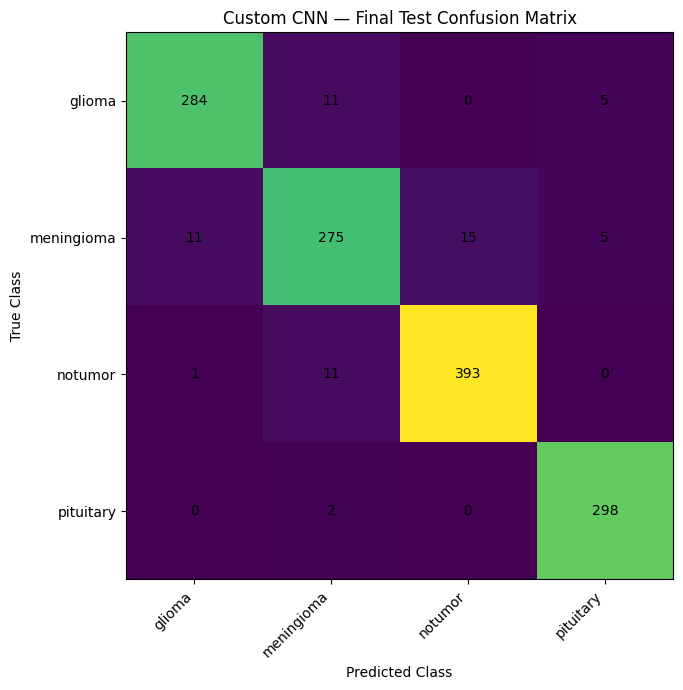

In [135]:
cm = confusion_matrix(
    test_true_indices,
    test_predicted_indices,
    labels=[0, 1, 2, 3]
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)


im = ax.imshow(cm)


ax.set_xticks(
    range(4)
)

ax.set_yticks(
    range(4)
)


ax.set_xticklabels(
    EXPECTED_CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    EXPECTED_CLASSES
)


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "Custom CNN — Final Test Confusion Matrix"
)


for i in range(4):

    for j in range(4):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()


plt.savefig(
    PLOTS_DIR /
    "cnn_test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

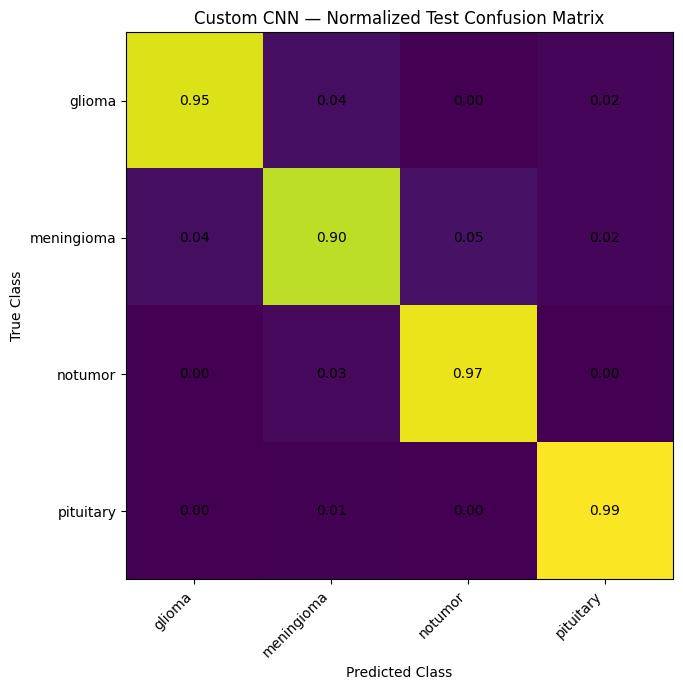

In [136]:
row_sums = cm.sum(
    axis=1,
    keepdims=True
)


cm_normalized = np.divide(
    cm,
    row_sums,

    out=np.zeros_like(
        cm,
        dtype=float
    ),

    where=row_sums != 0
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)


im = ax.imshow(
    cm_normalized,
    vmin=0,
    vmax=1
)


ax.set_xticks(
    range(4)
)

ax.set_yticks(
    range(4)
)


ax.set_xticklabels(
    EXPECTED_CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    EXPECTED_CLASSES
)


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "Custom CNN — Normalized Test Confusion Matrix"
)


for i in range(4):

    for j in range(4):

        ax.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center"
        )


plt.tight_layout()


plt.savefig(
    PLOTS_DIR /
    "cnn_test_confusion_matrix_normalized.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [137]:
test_true_binary = label_binarize(
    test_true_indices,
    classes=[0, 1, 2, 3]
)


roc_auc_macro = roc_auc_score(
    test_true_binary,
    test_probabilities,
    average="macro",
    multi_class="ovr"
)


roc_auc_weighted = roc_auc_score(
    test_true_binary,
    test_probabilities,
    average="weighted",
    multi_class="ovr"
)


print(
    "Macro OVR ROC-AUC:",
    round(
        roc_auc_macro,
        4
    )
)

print(
    "Weighted OVR ROC-AUC:",
    round(
        roc_auc_weighted,
        4
    )
)

Macro OVR ROC-AUC: 0.9932
Weighted OVR ROC-AUC: 0.993


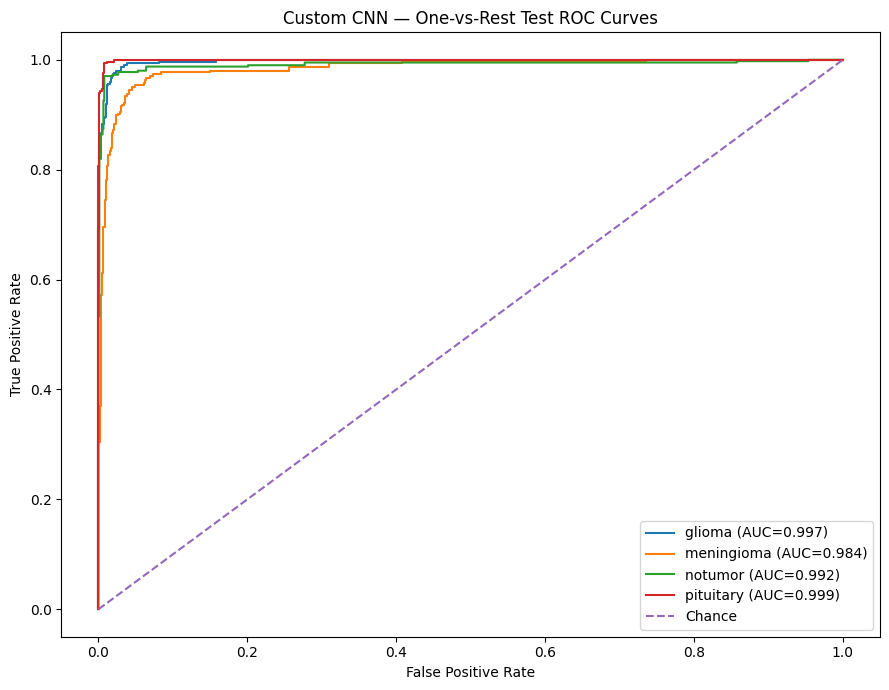


Per-class ROC-AUC:
glioma: 0.9973
meningioma: 0.9843
notumor: 0.9917
pituitary: 0.9993


In [138]:
plt.figure(
    figsize=(9, 7)
)


per_class_auc = {}


for class_index, class_name in enumerate(
    EXPECTED_CLASSES
):

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            test_true_binary[
                :,
                class_index
            ],

            test_probabilities[
                :,
                class_index
            ]
        )
    )


    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )


    per_class_auc[
        class_name
    ] = class_auc


    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{class_name} "
            f"(AUC={class_auc:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Custom CNN — One-vs-Rest Test ROC Curves"
)

plt.legend()
plt.tight_layout()


plt.savefig(
    PLOTS_DIR /
    "cnn_test_roc_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nPer-class ROC-AUC:")

for class_name, score in (
    per_class_auc.items()
):

    print(
        f"{class_name}: "
        f"{score:.4f}"
    )

In [139]:
SELECTED_HISTORY_PATH = (
    PHASE3_DIR /
    "histories" /
    f"{SELECTED_EXPERIMENT}_history.csv"
)


assert SELECTED_HISTORY_PATH.exists()


selected_history_df = pd.read_csv(
    SELECTED_HISTORY_PATH
)


display(
    selected_history_df
)

,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.612451,0.888879,0.594123,0.962980
1,2,0.759936,0.597160,0.661157,0.882224
2,3,0.815300,0.476515,0.848485,0.414214
3,4,0.842867,0.408102,0.864096,0.357849
4,5,0.869056,0.338485,0.824610,0.496655
5,6,0.887434,0.302738,0.899908,0.258711
6,7,0.899609,0.270579,0.865014,0.410111
7,8,0.914771,0.237731,0.912764,0.235580
8,9,0.927406,0.200918,0.921028,0.214260
9,10,0.929014,0.194360,0.893480,0.320502


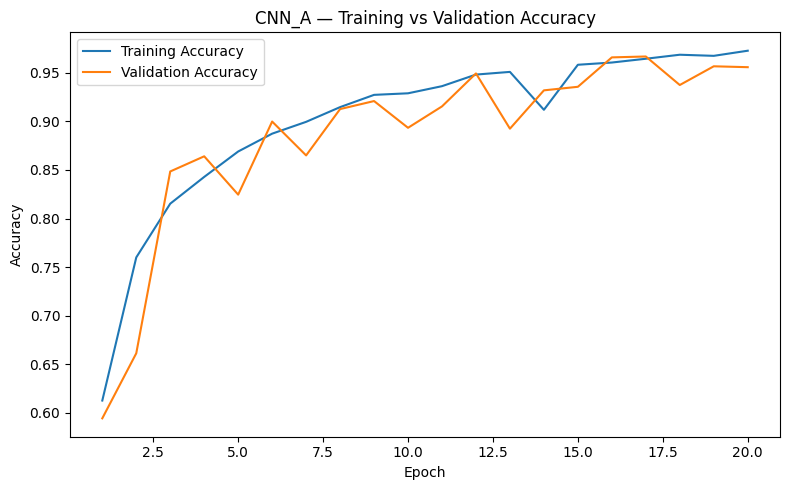

In [140]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    selected_history_df[
        "epoch"
    ],

    selected_history_df[
        "accuracy"
    ],

    label="Training Accuracy"
)


plt.plot(
    selected_history_df[
        "epoch"
    ],

    selected_history_df[
        "val_accuracy"
    ],

    label="Validation Accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    f"{SELECTED_EXPERIMENT} — "
    "Training vs Validation Accuracy"
)

plt.legend()
plt.tight_layout()


plt.savefig(
    PLOTS_DIR /
    "cnn_final_accuracy_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

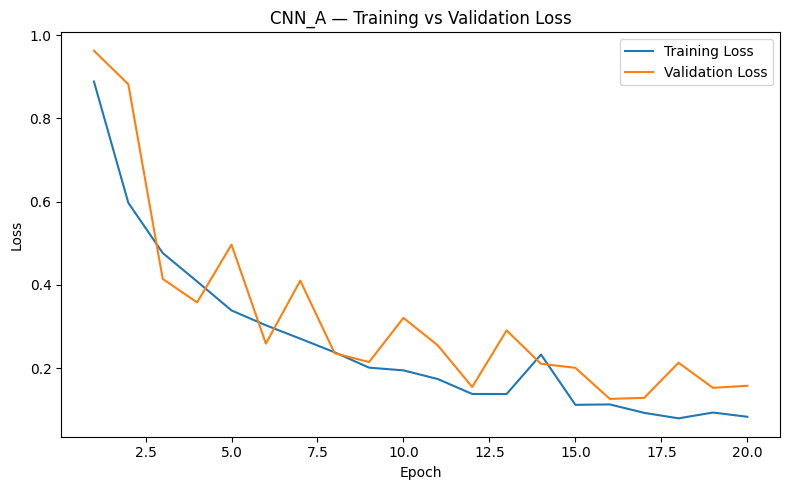

In [141]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    selected_history_df[
        "epoch"
    ],

    selected_history_df[
        "loss"
    ],

    label="Training Loss"
)


plt.plot(
    selected_history_df[
        "epoch"
    ],

    selected_history_df[
        "val_loss"
    ],

    label="Validation Loss"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    f"{SELECTED_EXPERIMENT} — "
    "Training vs Validation Loss"
)

plt.legend()
plt.tight_layout()


plt.savefig(
    PLOTS_DIR /
    "cnn_final_loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [142]:
PHASE3_SUMMARY_PATH = (
    PHASE3_DIR /
    "cnn_phase3_experiment_summary.csv"
)


phase3_summary_df = pd.read_csv(
    PHASE3_SUMMARY_PATH
)


selected_phase3_row = (
    phase3_summary_df[
        phase3_summary_df[
            "experiment_id"
        ] == SELECTED_EXPERIMENT
    ]
    .iloc[0]
)


actual_epochs = int(
    selected_phase3_row[
        "actual_epochs"
    ]
)


best_epoch = int(
    selected_phase3_row[
        "best_epoch"
    ]
)


training_time_seconds = float(
    selected_phase3_row[
        "training_time_seconds"
    ]
)


best_val_accuracy = float(
    selected_phase3_row[
        "best_val_accuracy"
    ]
)


best_val_loss = float(
    selected_phase3_row[
        "best_val_loss"
    ]
)


print(
    "Actual training epochs:",
    actual_epochs
)

print(
    "Best validation epoch:",
    best_epoch
)

print(
    "Training duration:",
    round(
        training_time_seconds,
        2
    ),
    "seconds"
)

print(
    "Best validation accuracy:",
    round(
        best_val_accuracy,
        4
    )
)

Actual training epochs: 20
Best validation epoch: 16
Training duration: 331.96 seconds
Best validation accuracy: 0.966


In [143]:
total_parameters = (
    final_cnn_model.count_params()
)


trainable_parameters = int(
    np.sum([
        np.prod(
            variable.shape
        )
        for variable
        in final_cnn_model.trainable_weights
    ])
)


non_trainable_parameters = (
    total_parameters
    -
    trainable_parameters
)


print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_parameters:,}"
)

Total parameters: 1,438,276
Trainable parameters: 1,438,276
Non-trainable parameters: 0


In [144]:
model_size_mb = (
    FINAL_CNN_CHECKPOINT
    .stat()
    .st_size
    /
    (1024 ** 2)
)


print(
    f"Saved model size: "
    f"{model_size_mb:.2f} MB"
)

Saved model size: 16.53 MB


In [145]:
timing_images, _ = next(
    iter(test_ds)
)


TIMING_WARMUP_RUNS = 5
TIMING_RUNS = 50


# Warm-up
for _ in range(
    TIMING_WARMUP_RUNS
):

    _ = final_cnn_model(
        timing_images,
        training=False
    )


# Synchronize by forcing tensor materialization
_ = final_cnn_model(
    timing_images,
    training=False
).numpy()


start_time = time.perf_counter()


for _ in range(
    TIMING_RUNS
):

    timed_output = final_cnn_model(
        timing_images,
        training=False
    )

    _ = timed_output.numpy()


elapsed_seconds = (
    time.perf_counter()
    -
    start_time
)


batch_size_used = int(
    timing_images.shape[0]
)


total_timed_images = (
    TIMING_RUNS
    *
    batch_size_used
)


seconds_per_image = (
    elapsed_seconds
    /
    total_timed_images
)


milliseconds_per_image = (
    seconds_per_image
    *
    1000
)


images_per_second = (
    1.0
    /
    seconds_per_image
)


print(
    "GPU:",
    gpu_name
)

print(
    "Batch size:",
    batch_size_used
)

print(
    "Warm-up runs:",
    TIMING_WARMUP_RUNS
)

print(
    "Timed runs:",
    TIMING_RUNS
)

print(
    f"Total timed duration: "
    f"{elapsed_seconds:.4f} sec"
)

print(
    f"Inference time/image: "
    f"{milliseconds_per_image:.4f} ms"
)

print(
    f"Throughput: "
    f"{images_per_second:.2f} images/sec"
)

GPU: Tesla T4
Batch size: 16
Warm-up runs: 5
Timed runs: 50
Total timed duration: 0.7437 sec
Inference time/image: 0.9296 ms
Throughput: 1075.70 images/sec


In [146]:
inference_timing = {

    "method":
        "model-only repeated batch forward pass",

    "batch_size":
        batch_size_used,

    "warmup_runs":
        TIMING_WARMUP_RUNS,

    "timed_runs":
        TIMING_RUNS,

    "total_timed_images":
        total_timed_images,

    "elapsed_seconds":
        elapsed_seconds,

    "milliseconds_per_image":
        milliseconds_per_image,

    "images_per_second":
        images_per_second,

    "gpu":
        gpu_name
}


with open(
    PHASE4_DIR /
    "cnn_inference_timing.json",
    "w"
) as file:

    json.dump(
        inference_timing,
        file,
        indent=4
    )

In [147]:
incorrect_predictions_df = (
    test_predictions_df[
        ~test_predictions_df[
            "correct"
        ]
    ]
    .copy()
)


incorrect_predictions_df.to_csv(
    ERROR_DIR /
    "cnn_misclassified_images.csv",
    index=False
)


print(
    "Correct predictions:",
    int(
        test_predictions_df[
            "correct"
        ].sum()
    )
)


print(
    "Misclassified predictions:",
    len(
        incorrect_predictions_df
    )
)


error_pairs = (
    incorrect_predictions_df
    .groupby(
        [
            "true_label",
            "predicted_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)


display(
    error_pairs
)


error_pairs.to_csv(
    ERROR_DIR /
    "cnn_error_pairs.csv",
    index=False
)

Correct predictions: 1250
Misclassified predictions: 61


,true_label,predicted_label,count
3,meningioma,notumor,15
0,glioma,meningioma,11
2,meningioma,glioma,11
6,notumor,meningioma,11
1,glioma,pituitary,5
4,meningioma,pituitary,5
7,pituitary,meningioma,2
5,notumor,glioma,1


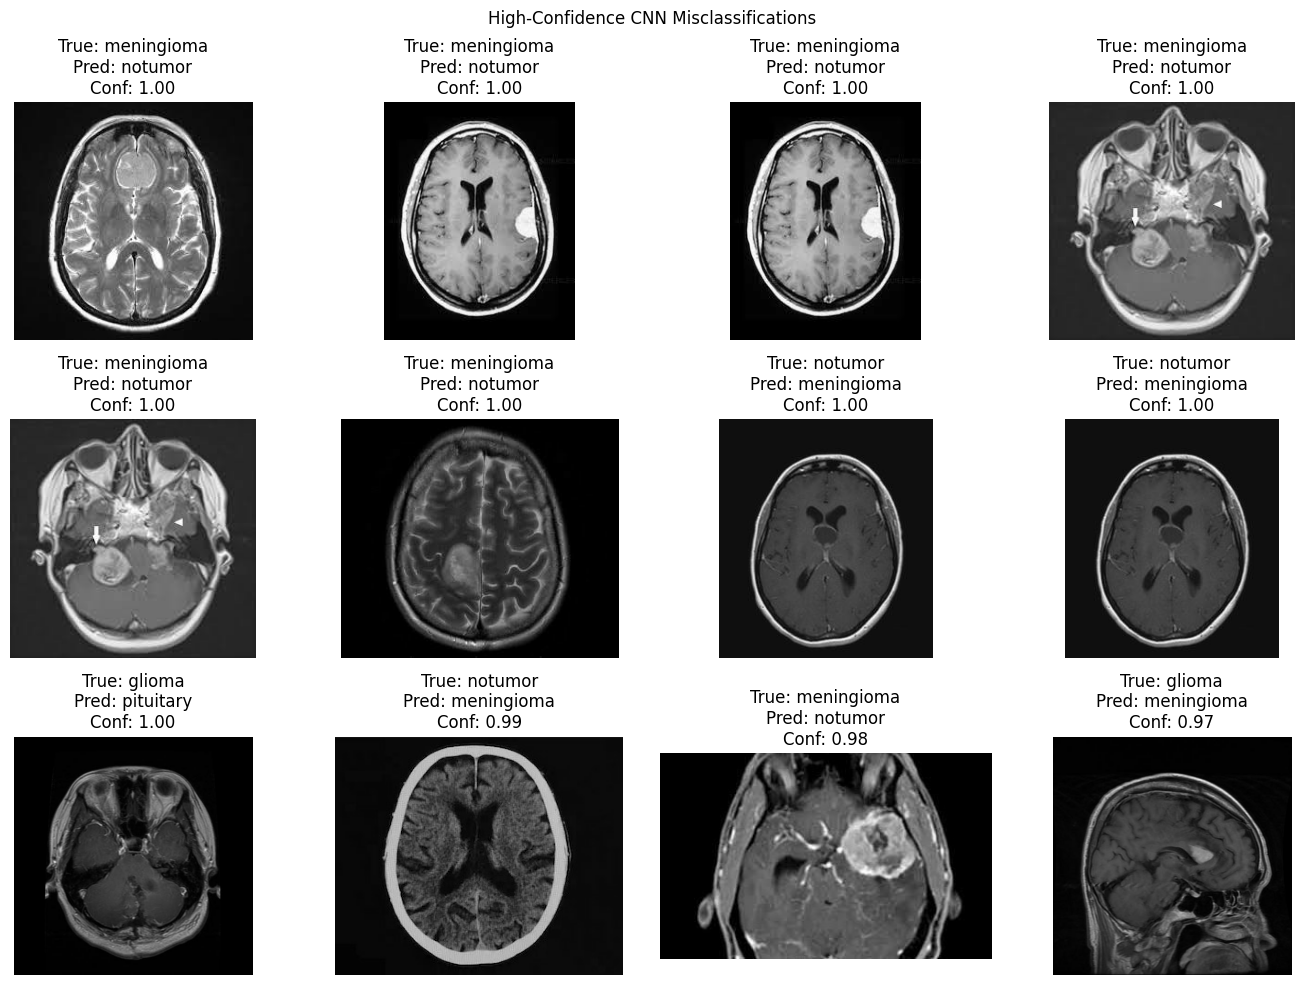

In [148]:
misclassified_sample = (
    incorrect_predictions_df
    .sort_values(
        "prediction_confidence",
        ascending=False
    )
    .head(12)
)


if len(
    misclassified_sample
) > 0:

    plt.figure(
        figsize=(14, 10)
    )


    for plot_index, (
        _,
        row
    ) in enumerate(
        misclassified_sample.iterrows()
    ):

        image_path = (
            DATASET_ROOT /
            row["filepath"]
        )


        image_bytes = tf.io.read_file(
            str(image_path)
        )


        image = tf.io.decode_image(
            image_bytes,
            channels=3,
            expand_animations=False
        )


        plt.subplot(
            3,
            4,
            plot_index + 1
        )


        plt.imshow(
            image.numpy()
            .astype(
                np.uint8
            )
        )


        plt.title(
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['prediction_confidence']:.2f}"
        )


        plt.axis("off")


    plt.suptitle(
        "High-Confidence CNN Misclassifications"
    )

    plt.tight_layout()


    plt.savefig(
        PLOTS_DIR /
        "cnn_misclassified_examples.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "No misclassified samples."
    )

In [149]:
per_class_summary = []

for class_index, class_name in enumerate(EXPECTED_CLASSES):
    class_mask = (test_true_indices == class_index)
    class_true = test_true_indices[class_mask]
    class_pred = test_predicted_indices[class_mask]
    class_accuracy = accuracy_score(class_true, class_pred)
    class_errors = int(np.sum(class_true != class_pred))

    per_class_summary.append({
        'class': class_name,
        'support': int(np.sum(class_mask)),
        'correct': int(np.sum(class_true == class_pred)),
        'errors': class_errors,
        'class_accuracy': float(class_accuracy),
        'roc_auc': float(per_class_auc[class_name]),
    })

per_class_summary_df = pd.DataFrame(per_class_summary)
display(per_class_summary_df)
per_class_summary_df.to_csv(
    PHASE4_DIR / 'cnn_test_per_class_summary.csv',
    index=False,
)

,class,support,correct,errors,class_accuracy,roc_auc
0,glioma,300,284,16,0.946667,0.997346
1,meningioma,306,275,31,0.898693,0.984291
2,notumor,405,393,12,0.970370,0.991676
3,pituitary,300,298,2,0.993333,0.999318


In [150]:
validation_test_gap = (
    best_val_accuracy
    -
    test_accuracy
)


print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Final test accuracy:      "
    f"{test_accuracy:.4f}"
)

print(
    f"Validation-test gap:      "
    f"{validation_test_gap:.4f}"
)


if abs(
    validation_test_gap
) < 0.03:

    print(
        "\nObservation: Validation and "
        "test accuracy are relatively close."
    )

elif validation_test_gap > 0.03:

    print(
        "\nObservation: Test performance "
        "is lower than validation performance."
    )

else:

    print(
        "\nObservation: Test accuracy "
        "is higher than validation accuracy."
    )


print(
    "\nThis difference should be interpreted "
    "together with class-level metrics, "
    "dataset composition and learning curves."
)

Best validation accuracy: 0.9660
Final test accuracy:      0.9535
Validation-test gap:      0.0126

Observation: Validation and test accuracy are relatively close.

This difference should be interpreted together with class-level metrics, dataset composition and learning curves.


In [151]:
FINAL_CNN_METRICS = {

    "model":
        "Custom CNN",

    "selected_experiment":
        SELECTED_EXPERIMENT,

    "dataset_version":
        1,

    "train_samples":
        4353,

    "validation_samples":
        1089,

    "test_samples":
        1311,

    "image_size":
        "224x224x3",

    "batch_size":
        16,

    "optimizer":
        "Adam",

    "learning_rate":
        0.001,

    "max_epochs":
        20,

    "actual_epochs":
        actual_epochs,

    "best_epoch":
        best_epoch,

    "best_val_loss":
        best_val_loss,

    "best_val_accuracy":
        best_val_accuracy,

    "test_loss":
        float(
            test_loss
        ),

    "test_accuracy":
        float(
            test_accuracy
        ),

    "macro_precision":
        float(
            macro_precision
        ),

    "macro_recall":
        float(
            macro_recall
        ),

    "macro_f1":
        float(
            macro_f1
        ),

    "weighted_precision":
        float(
            weighted_precision
        ),

    "weighted_recall":
        float(
            weighted_recall
        ),

    "weighted_f1":
        float(
            weighted_f1
        ),

    "roc_auc_macro":
        float(
            roc_auc_macro
        ),

    "roc_auc_weighted":
        float(
            roc_auc_weighted
        ),

    "training_time_seconds":
        training_time_seconds,

    "full_test_prediction_seconds":
        full_prediction_seconds,

    "inference_ms_per_image":
        milliseconds_per_image,

    "inference_images_per_second":
        images_per_second,

    "total_parameters":
        int(
            total_parameters
        ),

    "trainable_parameters":
        int(
            trainable_parameters
        ),

    "model_size_mb":
        float(
            model_size_mb
        ),

    "seed":
        42,

    "gpu":
        gpu_name,

    "test_used_only_after_model_selection":
        True,

    "patient_level_independence_verified":
        False
}


with open(
    PHASE4_DIR /
    "cnn_final_metrics.json",
    "w"
) as file:

    json.dump(
        FINAL_CNN_METRICS,
        file,
        indent=4
    )


pd.DataFrame(
    [FINAL_CNN_METRICS]
).to_csv(
    PHASE4_DIR /
    "cnn_final_metrics.csv",
    index=False
)


print(
    json.dumps(
        FINAL_CNN_METRICS,
        indent=4
    )
)

{
    "model": "Custom CNN",
    "selected_experiment": "CNN_A",
    "dataset_version": 1,
    "train_samples": 4353,
    "validation_samples": 1089,
    "test_samples": 1311,
    "image_size": "224x224x3",
    "batch_size": 16,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "max_epochs": 20,
    "actual_epochs": 20,
    "best_epoch": 16,
    "best_val_loss": 0.1257652640342712,
    "best_val_accuracy": 0.966023862361908,
    "test_loss": 0.19749495387077332,
    "test_accuracy": 0.9534706331045004,
    "macro_precision": 0.9524899156452865,
    "macro_recall": 0.9522657952069716,
    "macro_f1": 0.9522909672776282,
    "weighted_precision": 0.9532006096914769,
    "weighted_recall": 0.9534706331045004,
    "weighted_f1": 0.9532544785025558,
    "roc_auc_macro": 0.993157464256547,
    "roc_auc_weighted": 0.9929981944337567,
    "training_time_seconds": 331.9568198119996,
    "full_test_prediction_seconds": 4.047071742999833,
    "inference_ms_per_image": 0.9296289650001199,
 

In [152]:
selected_history_df.to_csv(
    PHASE4_DIR /
    "cnn_final_training_history.csv",
    index=False
)


print(
    "Final training history saved."
)

Final training history saved.


In [153]:
lowest_f1_class = (
    classification_report_df
    .loc[
        EXPECTED_CLASSES,
        "f1-score"
    ]
    .idxmin()
)


highest_f1_class = (
    classification_report_df
    .loc[
        EXPECTED_CLASSES,
        "f1-score"
    ]
    .idxmax()
)


if len(error_pairs) > 0:

    most_common_error = (
        error_pairs.iloc[0]
    )

    common_error_text = (
        f"{most_common_error['true_label']} "
        f"-> "
        f"{most_common_error['predicted_label']} "
        f"({int(most_common_error['count'])} cases)"
    )

else:

    common_error_text = (
        "No classification errors"
    )


OBSERVATIONS = {

    "lowest_test_f1_class":
        lowest_f1_class,

    "highest_test_f1_class":
        highest_f1_class,

    "most_common_error_pair":
        common_error_text,

    "validation_test_accuracy_gap":
        float(
            validation_test_gap
        ),

    "misclassified_images":
        int(
            len(
                incorrect_predictions_df
            )
        ),

    "dataset_limitation":
        (
            "Patient-level independence cannot "
            "be verified from available identifiers."
        ),

    "leakage_control":
        (
            "Exact duplicate overlap was audited "
            "before frozen splits were created."
        ),

    "interpretation_warning":
        (
            "Performance on this dataset does not "
            "establish performance on unseen "
            "patients, scanners, hospitals or "
            "clinical populations."
        )
}


with open(
    PHASE4_DIR /
    "cnn_evidence_notes.json",
    "w"
) as file:

    json.dump(
        OBSERVATIONS,
        file,
        indent=4
    )


print(
    json.dumps(
        OBSERVATIONS,
        indent=4
    )
)

{
    "lowest_test_f1_class": "meningioma",
    "highest_test_f1_class": "pituitary",
    "most_common_error_pair": "meningioma -> notumor (15 cases)",
    "validation_test_accuracy_gap": 0.012553229257407539,
    "misclassified_images": 61,
    "dataset_limitation": "Patient-level independence cannot be verified from available identifiers.",
    "leakage_control": "Exact duplicate overlap was audited before frozen splits were created.",
    "interpretation_warning": "Performance on this dataset does not establish performance on unseen patients, scanners, hospitals or clinical populations."
}


In [154]:
print("=" * 80)
print("MEMBER 1 — PHASE 4 FINAL SUMMARY")
print("=" * 80)


print(
    "Selected CNN:",
    SELECTED_EXPERIMENT
)

print(
    "GPU:",
    gpu_name
)


print("\nDATA")
print("-" * 40)

print(
    "Train:",
    4353
)

print(
    "Validation:",
    1089
)

print(
    "Test:",
    1311
)


print("\nPERFORMANCE")
print("-" * 40)

print(
    f"Test loss:        "
    f"{test_loss:.4f}"
)

print(
    f"Test accuracy:    "
    f"{test_accuracy:.4f}"
)

print(
    f"Macro precision:  "
    f"{macro_precision:.4f}"
)

print(
    f"Macro recall:     "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1:         "
    f"{macro_f1:.4f}"
)

print(
    f"Macro ROC-AUC:    "
    f"{roc_auc_macro:.4f}"
)


print("\nTRAINING")
print("-" * 40)

print(
    "Actual epochs:",
    actual_epochs
)

print(
    "Best epoch:",
    best_epoch
)

print(
    f"Best val accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Training time: "
    f"{training_time_seconds:.2f} sec"
)


print("\nCOMPLEXITY / EFFICIENCY")
print("-" * 40)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    f"Model size: "
    f"{model_size_mb:.2f} MB"
)

print(
    f"Inference: "
    f"{milliseconds_per_image:.4f} ms/image"
)

print(
    f"Throughput: "
    f"{images_per_second:.2f} images/sec"
)


print("\nERROR ANALYSIS")
print("-" * 40)

print(
    "Misclassified images:",
    len(
        incorrect_predictions_df
    )
)

print(
    "Lowest F1 class:",
    lowest_f1_class
)

print(
    "Highest F1 class:",
    highest_f1_class
)

print(
    "Most common confusion:",
    common_error_text
)


print("\nGENERALIZATION")
print("-" * 40)

print(
    f"Validation-test accuracy gap: "
    f"{validation_test_gap:.4f}"
)

print(
    "Patient-level independence verified: NO"
)


print("\nPHASE 4 STATUS")
print("-" * 40)

print("✓ Frozen Phase 3 checkpoint used")
print("✓ Held-out test evaluated")
print("✓ Test loss calculated")
print("✓ Test accuracy calculated")
print("✓ Macro precision calculated")
print("✓ Macro recall calculated")
print("✓ Macro F1 calculated")
print("✓ Weighted metrics calculated")
print("✓ Per-class metrics calculated")
print("✓ Confusion matrix generated")
print("✓ Normalized confusion matrix generated")
print("✓ Multiclass ROC-AUC calculated")
print("✓ ROC curves generated")
print("✓ Predictions saved with probabilities")
print("✓ Learning curves preserved")
print("✓ Parameter count recorded")
print("✓ Model size recorded")
print("✓ Training duration recorded")
print("✓ Standardized inference timing recorded")
print("✓ Error analysis completed")
print("✓ Test results saved")
print("✓ No post-test model tuning performed")

MEMBER 1 — PHASE 4 FINAL SUMMARY
Selected CNN: CNN_A
GPU: Tesla T4

DATA
----------------------------------------
Train: 4353
Validation: 1089
Test: 1311

PERFORMANCE
----------------------------------------
Test loss:        0.1975
Test accuracy:    0.9535
Macro precision:  0.9525
Macro recall:     0.9523
Macro F1:         0.9523
Macro ROC-AUC:    0.9932

TRAINING
----------------------------------------
Actual epochs: 20
Best epoch: 16
Best val accuracy: 0.9660
Training time: 331.96 sec

COMPLEXITY / EFFICIENCY
----------------------------------------
Total parameters: 1,438,276
Trainable parameters: 1,438,276
Model size: 16.53 MB
Inference: 0.9296 ms/image
Throughput: 1075.70 images/sec

ERROR ANALYSIS
----------------------------------------
Misclassified images: 61
Lowest F1 class: meningioma
Highest F1 class: pituitary
Most common confusion: meningioma -> notumor (15 cases)

GENERALIZATION
----------------------------------------
Validation-test accuracy gap: 0.0126
Patient-level

In [155]:
print('Interactive ZIP/download export skipped during reproducibility Run All.')
print('All experiment artifacts are already written under PROJECT_DIR/results/.')

MEMBER 1 — PHASE 1 TO PHASE 4 EXPORT
ZIP created:
/content/member1_cnn_phases1_to4.zip

ZIP size: 68.89 MB

Included project folders:
✓ config
✓ requirements.txt
✓ results
✓ splits

Dataset images are NOT included.
Kaggle dataset can be downloaded again using version 1.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [156]:
import os
import sys
import json
import time
import hashlib
import shutil
import platform
import importlib.metadata

from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras


# ---------------------------------------------------------
# Core project locations
# ---------------------------------------------------------

PROJECT_DIR = PROJECT_ROOT

SPLITS_DIR = (
    PROJECT_DIR /
    "splits"
)

PHASE3_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase3_experiments"
)

PHASE4_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase4_final_test"
)

FINALIZATION_DIR = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "phase5_finalization"
)

MODELS_DIR = (
    PROJECT_DIR /
    "models" /
    "cnn"
)

DOCS_DIR = (
    PROJECT_DIR /
    "docs"
)


for directory in [
    FINALIZATION_DIR,
    MODELS_DIR,
    DOCS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ---------------------------------------------------------
# Required files
# ---------------------------------------------------------

required_files = {

    "train.csv":
        SPLITS_DIR / "train.csv",

    "val.csv":
        SPLITS_DIR / "val.csv",

    "test.csv":
        SPLITS_DIR / "test.csv",

    "split_checksums.json":
        SPLITS_DIR / "split_checksums.json",

    "selected CNN checkpoint":
        PHASE3_DIR / "selected_cnn_best.keras",

    "selected CNN configuration":
        PHASE3_DIR / "selected_cnn_configuration.json",

    "Phase 3 experiment summary":
        PHASE3_DIR / "cnn_phase3_experiment_summary.csv",

    "final CNN metrics JSON":
        PHASE4_DIR / "cnn_final_metrics.json",

    "final CNN metrics CSV":
        PHASE4_DIR / "cnn_final_metrics.csv",

    "test predictions":
        PHASE4_DIR / "cnn_test_predictions.csv",

    "classification report":
        PHASE4_DIR / "cnn_test_classification_report.csv",

    "training history":
        PHASE4_DIR / "cnn_final_training_history.csv",

    "inference timing":
        PHASE4_DIR / "cnn_inference_timing.json",

    "evidence notes":
        PHASE4_DIR / "cnn_evidence_notes.json"
}


missing_files = []


for name, path in required_files.items():

    exists = path.exists()

    print(
        f"{name:<32} : "
        f"{'✓ FOUND' if exists else '✗ MISSING'}"
    )

    if not exists:
        missing_files.append(
            (name, str(path))
        )


if missing_files:

    raise RuntimeError(
        "Phase 5 cannot continue because "
        "required files are missing:\n"
        +
        "\n".join(
            f"- {name}: {path}"
            for name, path
            in missing_files
        )
    )


print(
    "\n✓ Phase 1–4 outputs are available."
)

train.csv                        : ✓ FOUND
val.csv                          : ✓ FOUND
test.csv                         : ✓ FOUND
split_checksums.json             : ✓ FOUND
selected CNN checkpoint          : ✓ FOUND
selected CNN configuration       : ✓ FOUND
Phase 3 experiment summary       : ✓ FOUND
final CNN metrics JSON           : ✓ FOUND
final CNN metrics CSV            : ✓ FOUND
test predictions                 : ✓ FOUND
classification report            : ✓ FOUND
training history                 : ✓ FOUND
inference timing                 : ✓ FOUND
evidence notes                   : ✓ FOUND

✓ Phase 1–4 outputs are available.


In [157]:
EXPECTED_SPLIT_CHECKSUMS = {

    "train.csv":
        "7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb",

    "val.csv":
        "37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f",

    "test.csv":
        "9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39"
}


def sha256_file(file_path):

    hasher = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file:

        for chunk in iter(
            lambda:
            file.read(
                1024 * 1024
            ),
            b""
        ):

            hasher.update(chunk)

    return hasher.hexdigest()


for filename, expected_hash in (
    EXPECTED_SPLIT_CHECKSUMS.items()
):

    file_path = (
        SPLITS_DIR /
        filename
    )

    actual_hash = sha256_file(
        file_path
    )

    assert actual_hash == expected_hash, (
        f"{filename} changed!"
    )

    print(
        f"✓ {filename}: MATCH"
    )


print(
    "\n✓ Dataset split contract "
    "remains unchanged."
)

✓ train.csv: MATCH
✓ val.csv: MATCH
✓ test.csv: MATCH

✓ Dataset split contract remains unchanged.


In [158]:
with open(
    PHASE4_DIR /
    "cnn_final_metrics.json",
    "r"
) as file:

    final_metrics = json.load(
        file
    )


with open(
    PHASE3_DIR /
    "selected_cnn_configuration.json",
    "r"
) as file:

    selected_configuration = (
        json.load(file)
    )


phase3_results = pd.read_csv(
    PHASE3_DIR /
    "cnn_phase3_experiment_summary.csv"
)


SELECTED_EXPERIMENT = (
    selected_configuration[
        "selected_experiment"
    ]
)


selected_phase3 = (
    phase3_results[
        phase3_results[
            "experiment_id"
        ] == SELECTED_EXPERIMENT
    ]
    .iloc[0]
)


print(
    "Selected experiment:",
    SELECTED_EXPERIMENT
)

print(
    "Final test accuracy:",
    final_metrics[
        "test_accuracy"
    ]
)

print(
    "Final Macro F1:",
    final_metrics[
        "macro_f1"
    ]
)

print(
    "Final Macro ROC-AUC:",
    final_metrics[
        "roc_auc_macro"
    ]
)

Selected experiment: CNN_A
Final test accuracy: 0.9534706331045004
Final Macro F1: 0.9522909672776282
Final Macro ROC-AUC: 0.993157464256547


In [159]:
SOURCE_MODEL = (
    PHASE3_DIR /
    "selected_cnn_best.keras"
)

FINAL_MODEL_PATH = (
    MODELS_DIR /
    "custom_cnn_final.keras"
)


shutil.copy2(
    SOURCE_MODEL,
    FINAL_MODEL_PATH
)


print(
    "Official CNN model:"
)

print(
    FINAL_MODEL_PATH
)

print(
    "\nSize:",
    round(
        FINAL_MODEL_PATH.stat().st_size
        /
        (1024 ** 2),
        2
    ),
    "MB"
)


print(
    "\nSHA-256:"
)

print(
    sha256_file(
        FINAL_MODEL_PATH
    )
)

Official CNN model:
/content/brain_tumour_model_comparison/models/cnn/custom_cnn_final.keras

Size: 16.53 MB

SHA-256:
a63268648fefa6dfa3de9fe74acd9626f056f22ef49f841efd524fa64fde1ede


In [160]:
verification_model = (
    keras.models.load_model(
        FINAL_MODEL_PATH
    )
)


print(
    "Model:",
    verification_model.name
)

print(
    "Input:",
    verification_model.input_shape
)

print(
    "Output:",
    verification_model.output_shape
)

print(
    "Parameters:",
    f"{verification_model.count_params():,}"
)


assert (
    verification_model.input_shape
    ==
    (None, 224, 224, 3)
)


assert (
    verification_model.output_shape
    ==
    (None, 4)
)


print(
    "\n✓ Final model can be "
    "loaded successfully."
)

Model: CNN_A
Input: (None, 224, 224, 3)
Output: (None, 4)
Parameters: 1,438,276

✓ Final model can be loaded successfully.


In [161]:
cnn_comparison_row = {

    "model":
        "Custom CNN",

    "experiment_id":
        SELECTED_EXPERIMENT,

    "image_size":
        "224x224x3",

    "batch_size":
        16,

    "optimizer":
        "Adam",

    "learning_rate":
        0.001,

    "max_epochs":
        20,

    "actual_epochs":
        int(
            final_metrics[
                "actual_epochs"
            ]
        ),

    "best_epoch":
        int(
            final_metrics[
                "best_epoch"
            ]
        ),

    "best_val_accuracy":
        float(
            final_metrics[
                "best_val_accuracy"
            ]
        ),

    "test_accuracy":
        float(
            final_metrics[
                "test_accuracy"
            ]
        ),

    "macro_precision":
        float(
            final_metrics[
                "macro_precision"
            ]
        ),

    "macro_recall":
        float(
            final_metrics[
                "macro_recall"
            ]
        ),

    "macro_f1":
        float(
            final_metrics[
                "macro_f1"
            ]
        ),

    "roc_auc_macro":
        float(
            final_metrics[
                "roc_auc_macro"
            ]
        ),

    "training_time_seconds":
        float(
            final_metrics[
                "training_time_seconds"
            ]
        ),

    "inference_time":
        float(
            final_metrics[
                "inference_ms_per_image"
            ]
        ),

    "inference_time_unit":
        "milliseconds_per_image",

    "total_parameters":
        int(
            final_metrics[
                "total_parameters"
            ]
        ),

    "trainable_parameters":
        int(
            final_metrics[
                "trainable_parameters"
            ]
        ),

    "model_size_mb":
        float(
            final_metrics[
                "model_size_mb"
            ]
        ),

    "seed":
        42,

    "gpu":
        final_metrics[
            "gpu"
        ],

    "dataset_version":
        1,

    "test_samples":
        1311,

    "patient_level_independence_verified":
        False
}


comparison_df = pd.DataFrame(
    [cnn_comparison_row]
)


comparison_df.to_csv(
    FINALIZATION_DIR /
    "cnn_comparison_row.csv",
    index=False
)


display(
    comparison_df
)

,model,experiment_id,image_size,batch_size,optimizer,learning_rate,max_epochs,actual_epochs,best_epoch,best_val_accuracy,...,inference_time,inference_time_unit,total_parameters,trainable_parameters,model_size_mb,seed,gpu,dataset_version,test_samples,patient_level_independence_verified
0,Custom CNN,CNN_A,224x224x3,16,Adam,0.001,20,20,16,0.966024,...,0.929629,milliseconds_per_image,1438276,1438276,16.529381,42,Tesla T4,1,1311,False


In [162]:
try:

    keras.utils.plot_model(
        verification_model,

        to_file=str(
            FINALIZATION_DIR /
            "custom_cnn_architecture.png"
        ),

        show_shapes=True,

        show_layer_names=True,

        expand_nested=True,

        dpi=120
    )

    print(
        "✓ Architecture diagram created."
    )

except Exception as error:

    print(
        "Architecture diagram could not "
        "be automatically generated."
    )

    print(
        "Reason:",
        error
    )

✓ Architecture diagram created.


In [163]:
test_accuracy = float(
    final_metrics[
        "test_accuracy"
    ]
)

macro_precision = float(
    final_metrics[
        "macro_precision"
    ]
)

macro_recall = float(
    final_metrics[
        "macro_recall"
    ]
)

macro_f1 = float(
    final_metrics[
        "macro_f1"
    ]
)

roc_auc_macro = float(
    final_metrics[
        "roc_auc_macro"
    ]
)

total_parameters = int(
    final_metrics[
        "total_parameters"
    ]
)

trainable_parameters = int(
    final_metrics[
        "trainable_parameters"
    ]
)

model_size_mb = float(
    final_metrics[
        "model_size_mb"
    ]
)

training_seconds = float(
    final_metrics[
        "training_time_seconds"
    ]
)

inference_ms = float(
    final_metrics[
        "inference_ms_per_image"
    ]
)


MODEL_CARD = f"""
# Custom CNN Model Card

## Project

Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification

## Model

Custom Convolutional Neural Network trained from scratch.

Selected validation experiment:

**{SELECTED_EXPERIMENT}**

The final model configuration was selected using training and validation data only. The held-out test dataset was evaluated only after the configuration was frozen.

## Dataset

Dataset:
Masoud Nickparvar — Brain Tumor MRI Dataset

Pinned Kaggle handle:

`masoudnickparvar/brain-tumor-mri-dataset/versions/1`

Classes:

1. glioma
2. meningioma
3. notumor
4. pituitary

Frozen dataset sizes:

- Training: 4,353 images
- Validation: 1,089 images
- Test: 1,311 images

The original Testing directory was preserved as the final held-out test set.

During the dataset audit:

- 191 exact duplicate copies inside the original Training data were excluded.
- 79 Training images with exact byte-identical matches in Testing were excluded from the Training candidate pool.
- No corrupt image files were detected.

Patient-level independence could not be independently verified because reliable patient identifiers were not available.

## Input

Image size:

`224 × 224 × 3`

Batch size:

`16`

## Preprocessing

The Custom CNN uses:

`Rescaling(1./255)`

Pixel normalization is performed inside the model.

Training-only augmentation:

- rotation factor: 0.03
- zoom: approximately ±0.08
- translation: 0.05

No random augmentation is applied during validation or test evaluation.

## Architecture

Core convolutional feature extractor:

`32 → 64 → 128 → 256`

Each convolution uses:

- 3 × 3 kernels
- ReLU activation
- MaxPooling

The classifier configuration corresponds to the selected Phase 3 experiment:

`{SELECTED_EXPERIMENT}`

The output layer contains four softmax units.

## Training Configuration

Optimizer:

`Adam`

Initial learning rate:

`0.001`

Loss:

`SparseCategoricalCrossentropy`

Maximum training budget:

`20 epochs`

Early stopping:

- Monitor: validation loss
- Patience: 4
- Restore/select best validation-loss checkpoint

Random seed:

`42`

## Final Evaluation

Test accuracy:

`{test_accuracy:.6f}`

Macro precision:

`{macro_precision:.6f}`

Macro recall:

`{macro_recall:.6f}`

Macro F1:

`{macro_f1:.6f}`

Macro one-vs-rest ROC-AUC:

`{roc_auc_macro:.6f}`

## Complexity and Efficiency

Total parameters:

`{total_parameters:,}`

Trainable parameters:

`{trainable_parameters:,}`

Saved model size:

`{model_size_mb:.2f} MB`

Training time:

`{training_seconds:.2f} seconds`

Standardized model-only inference time:

`{inference_ms:.4f} ms/image`

Hardware:

`{final_metrics["gpu"]}`

## Important Limitations

The reported performance applies to this dataset and experimental split.

Patient-level separation could not be independently verified.

Good performance on this dataset does not establish equivalent performance on unseen hospitals, MRI scanners, acquisition protocols, patient populations or real clinical environments.

The model is an academic image-classification experiment and is not a clinical diagnostic system.

## Reproducibility

Dataset version: `1`

Seed: `42`

Frozen split manifests and their SHA-256 checksums are distributed with the project.

The exact final model is stored as:

`models/cnn/custom_cnn_final.keras`
"""


MODEL_CARD_PATH = (
    PROJECT_DIR /
    "results" /
    "cnn" /
    "MODEL_CARD.md"
)


MODEL_CARD_PATH.write_text(
    MODEL_CARD,
    encoding="utf-8"
)


print(
    MODEL_CARD
)


# Custom CNN Model Card

## Project

Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification

## Model

Custom Convolutional Neural Network trained from scratch.

Selected validation experiment:

**CNN_A**

The final model configuration was selected using training and validation data only. The held-out test dataset was evaluated only after the configuration was frozen.

## Dataset

Dataset:
Masoud Nickparvar — Brain Tumor MRI Dataset

Pinned Kaggle handle:

`masoudnickparvar/brain-tumor-mri-dataset/versions/1`

Classes:

1. glioma
2. meningioma
3. notumor
4. pituitary

Frozen dataset sizes:

- Training: 4,353 images
- Validation: 1,089 images
- Test: 1,311 images

The original Testing directory was preserved as the final held-out test set.

During the dataset audit:

- 191 exact duplicate copies inside the original Training data were excluded.
- 79 Training images with exact byte-identical matches in Testing were excluded from the Training c

In [164]:
HANDOFF_TEXT = """
# Shared Dataset Handoff

## Dataset

Masoud Nickparvar — Brain Tumor MRI Dataset

Pinned version:

masoudnickparvar/brain-tumor-mri-dataset/versions/1

Do NOT use the unversioned latest dataset handle.

## Frozen Splits

Training:
4,353 images

Validation:
1,089 images

Test:
1,311 images

Members 2, 3 and 4 MUST load these manifests directly:

splits/train.csv
splits/val.csv
splits/test.csv

They MUST NOT execute train_test_split() again.

## SHA-256 Manifest Checksums

train.csv

7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb

val.csv

37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f

test.csv

9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39

If any checksum differs, stop before model development.

## Class Mapping

glioma = 0
meningioma = 1
notumor = 2
pituitary = 3

Do not change the mapping.

## Shared Experimental Protocol

Image size:
224 × 224 × 3

Batch size:
16

Random seed:
42

Maximum epoch budget:
20

Early stopping:
monitor val_loss
patience 4
restore/select best validation checkpoint

Training augmentation:
same conservative rotation, zoom and translation policy used by CNN.

Testing:
held out until each member has selected their final configuration using validation results.

## Architecture-Specific Preprocessing

Custom CNN:
Rescaling(1./255)

VGG16:
keras.applications.vgg16.preprocess_input

ResNet50:
keras.applications.resnet50.preprocess_input

DenseNet121:
keras.applications.densenet.preprocess_input

Do NOT apply Rescaling(1./255) before an application-specific preprocess_input unless the architecture explicitly requires it.

## Standard Inference Timing

Use:

batch size = 16
warm-up runs = 5
timed runs = 50
training=False

Time already-decoded tensors so model computation is compared rather than filesystem speed.

Use the same GPU where possible and always record the actual hardware.

## Dataset Limitations

Exact duplicate leakage was audited before the frozen split was created.

Reliable patient identifiers were not established.

Therefore patient-level independence must not be claimed.
"""


HANDOFF_PATH = (
    DOCS_DIR /
    "SHARED_DATA_HANDOFF.md"
)


HANDOFF_PATH.write_text(
    HANDOFF_TEXT,
    encoding="utf-8"
)


print(
    HANDOFF_TEXT
)


# Shared Dataset Handoff

## Dataset

Masoud Nickparvar — Brain Tumor MRI Dataset

Pinned version:

masoudnickparvar/brain-tumor-mri-dataset/versions/1

Do NOT use the unversioned latest dataset handle.

## Frozen Splits

Training:
4,353 images

Validation:
1,089 images

Test:
1,311 images

Members 2, 3 and 4 MUST load these manifests directly:

splits/train.csv
splits/val.csv
splits/test.csv

They MUST NOT execute train_test_split() again.

## SHA-256 Manifest Checksums

train.csv

7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb

val.csv

37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f

test.csv

9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39

If any checksum differs, stop before model development.

## Class Mapping

glioma = 0
meningioma = 1
notumor = 2
pituitary = 3

Do not change the mapping.

## Shared Experimental Protocol

Image size:
224 × 224 × 3

Batch size:
16

Random seed:
42

Maximum epoch budget:
20

Early stopping:
mon

In [165]:
MODEL_README = """
# Trained Models

Large trained model checkpoints are not required to be committed directly to the standard Git repository.

The official final Custom CNN checkpoint is:

custom_cnn_final.keras

It was selected using validation performance before the held-out test set was evaluated.

Development checkpoints from CNN-A, CNN-B and CNN-C are experimental artifacts and do not need to be distributed as final models.

If model files are stored externally, document their location and checksum here.
"""


MODELS_README_PATH = (
    PROJECT_DIR /
    "models" /
    "README.md"
)


MODELS_README_PATH.write_text(
    MODEL_README,
    encoding="utf-8"
)


print(
    MODEL_README
)


# Trained Models

Large trained model checkpoints are not required to be committed directly to the standard Git repository.

The official final Custom CNN checkpoint is:

custom_cnn_final.keras

It was selected using validation performance before the held-out test set was evaluated.

Development checkpoints from CNN-A, CNN-B and CNN-C are experimental artifacts and do not need to be distributed as final models.

If model files are stored externally, document their location and checksum here.



In [166]:
GITIGNORE_CONTENT = """
# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Local datasets
data/
dataset/
Training/
Testing/
brain-tumor-mri-dataset/

# Model checkpoints
*.keras
*.h5
*.hdf5

# Colab / local temporary files
*.zip
.DS_Store
"""


GITIGNORE_PATH = (
    PROJECT_DIR /
    ".gitignore"
)


GITIGNORE_PATH.write_text(
    GITIGNORE_CONTENT.strip()
    + "\n",
    encoding="utf-8"
)


print(
    GITIGNORE_PATH.read_text()
)

# Python
__pycache__/
*.pyc

# Jupyter
.ipynb_checkpoints/

# Local datasets
data/
dataset/
Training/
Testing/
brain-tumor-mri-dataset/

# Model checkpoints
*.keras
*.h5
*.hdf5

# Colab / local temporary files
*.zip
.DS_Store



In [167]:
def package_version(
    package_name
):

    try:

        return importlib.metadata.version(
            package_name
        )

    except Exception:

        return "unknown"


FINAL_ENVIRONMENT = {

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "tensorflow":
        tf.__version__,

    "keras":
        package_version(
            "keras"
        ),

    "numpy":
        package_version(
            "numpy"
        ),

    "pandas":
        package_version(
            "pandas"
        ),

    "scikit_learn":
        package_version(
            "scikit-learn"
        ),

    "kagglehub":
        package_version(
            "kagglehub"
        ),

    "pillow":
        package_version(
            "Pillow"
        ),

    "imagehash":
        package_version(
            "ImageHash"
        ),

    "seed":
        42,

    "dataset_version":
        1,

    "selected_cnn":
        SELECTED_EXPERIMENT,

    "gpu":
        final_metrics[
            "gpu"
        ]
}


with open(
    FINALIZATION_DIR /
    "cnn_environment.json",
    "w"
) as file:

    json.dump(
        FINAL_ENVIRONMENT,
        file,
        indent=4
    )


print(
    json.dumps(
        FINAL_ENVIRONMENT,
        indent=4
    )
)

{
    "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
    "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
    "tensorflow": "2.20.0",
    "keras": "3.13.2",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "scikit_learn": "1.6.1",
    "kagglehub": "1.0.2",
    "pillow": "11.3.0",
    "imagehash": "unknown",
    "seed": 42,
    "dataset_version": 1,
    "selected_cnn": "CNN_A",
    "gpu": "Tesla T4"
}


In [168]:
def requirement_line(package_name, import_version=None):
    version = package_version(package_name)
    return package_name if version == 'unknown' else f'{package_name}=={version}'

requirements = [
    requirement_line('tensorflow'),
    requirement_line('keras'),
    requirement_line('numpy'),
    requirement_line('pandas'),
    requirement_line('scikit-learn'),
    requirement_line('kagglehub'),
    requirement_line('Pillow'),
    requirement_line('ImageHash'),
    requirement_line('matplotlib'),
    requirement_line('seaborn'),
]

requirements_path = PROJECT_DIR / 'requirements.txt'
requirements_path.write_text('\n'.join(requirements) + '\n', encoding='utf-8')
print(requirements_path.read_text())

tensorflow==2.20.0
keras==3.13.2
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
kagglehub==1.0.2
Pillow==11.3.0
ImageHash==unknown



In [169]:
REPRODUCIBILITY_CONFIG = {

    "project":
        (
            "Comparative Analysis of Deep Learning "
            "Architectures for Multi-Class Brain "
            "Tumour MRI Classification"
        ),

    "member":
        1,

    "architecture":
        "Custom CNN",

    "selected_experiment":
        SELECTED_EXPERIMENT,

    "dataset":
        (
            "masoudnickparvar/"
            "brain-tumor-mri-dataset/"
            "versions/1"
        ),

    "dataset_fingerprint":
        (
            "061cbffb7341abf85e57a4f99de571e8"
            "fa4702ec8236c929e35543ab0547217d"
        ),

    "split_checksums":
        EXPECTED_SPLIT_CHECKSUMS,

    "train_samples":
        4353,

    "validation_samples":
        1089,

    "test_samples":
        1311,

    "seed":
        42,

    "image_size":
        [224, 224, 3],

    "class_mapping": {
        "glioma": 0,
        "meningioma": 1,
        "notumor": 2,
        "pituitary": 3
    },

    "test_used_only_after_model_selection":
        True,

    "post_test_model_tuning_performed":
        False,

    "patient_level_independence_verified":
        False
}


with open(
    FINALIZATION_DIR /
    "cnn_reproducibility_config.json",
    "w"
) as file:

    json.dump(
        REPRODUCIBILITY_CONFIG,
        file,
        indent=4
    )


print(
    json.dumps(
        REPRODUCIBILITY_CONFIG,
        indent=4
    )
)

{
    "project": "Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification",
    "member": 1,
    "architecture": "Custom CNN",
    "selected_experiment": "CNN_A",
    "dataset": "masoudnickparvar/brain-tumor-mri-dataset/versions/1",
    "dataset_fingerprint": "061cbffb7341abf85e57a4f99de571e8fa4702ec8236c929e35543ab0547217d",
    "split_checksums": {
        "train.csv": "7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb",
        "val.csv": "37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f",
        "test.csv": "9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39"
    },
    "train_samples": 4353,
    "validation_samples": 1089,
    "test_samples": 1311,
    "seed": 42,
    "image_size": [
        224,
        224,
        3
    ],
    "class_mapping": {
        "glioma": 0,
        "meningioma": 1,
        "notumor": 2,
        "pituitary": 3
    },
    "test_used_only_after_model_selection": true